In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
from IPython.display import display, HTML
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error, auc, roc_curve, roc_auc_score
from decimal import Decimal
import geopandas as gpd
from shapely.geometry import Point
from scipy.interpolate import griddata
import rasterio
from rasterio.transform import from_origin

# Get multiple outputs in the same cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Ignore all warnings
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings(action='ignore', category=DeprecationWarning)
pd.set_option('display.max_columns', None)

## Data preparation

In [87]:
# Read in the data 
# We have two dataframes with same column but different data 
# I believe we should have one dataframe contain information about both dataframes (presence and absence)

# Here I was reading in old data. Just want to show Kyle the difference between old and new data
# presence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/points_data/points_of_presence_test_old.csv', delimiter=';')
# absence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/points_data/points_of_absence_test_old.csv', delimiter=';')

presence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_for_training/standardised_points_of_presence.csv', delimiter=';')
absence_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_for_training/standardised_points_of_absence.csv', delimiter=';')

print("Presence info", presence_df.shape)
print("Absence info", absence_df.shape)

Presence info (46110, 23)
Absence info (46110, 23)


In [88]:
# Head for points of presence data
print("Points of presence")
presence_df.head()

# Head for points of absence data
print("Points of absence")
absence_df.head()

Points of presence


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc_fuzzy_linear,sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear,sudem_1000m_albers_twi_d8_wc_fuzzy_linear,sudem_1000m_albers_slope_degree_wc_fuzzy_linear,sudem_1000m_albers_slope_wc_fuzzy_linear,sudem_1000m_albers_aspect_wc_fuzzy_linear,sudem_1000m_albers_flow_network_wc_fuzzy_linear,sudem_1000m_albers_curvature_wc_fuzzy_linear,composite_temp_mean_1000m_k30_wc_fuzzy_linear,composite_temp_min_1000m_k30_wc_fuzzy_linear,composite_temp_max_1000m_k30_wc_fuzzy_linear,composite_rainfall_sum_1000m_k30_wc_fuzzy_linear,composite_gdd_grapes_1000m_wc_fuzzy_linear,composite_AETI_1000m_albers_wc_fuzzy_linear,nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear,sand_0_to_5cm_1000m_albers_wc_fuzzy_linear,soc_0_to_5cm_1000m_albers_wc_fuzzy_linear,clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear,soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear,silt_0_to_5cm_1000m_albers_wc_fuzzy_linear
0,1,"19,552906066300000","-33,503039127100003","0,1652253","0,6844613","0,1934858","0,0095941","0,0042619","0,3894892","0,5880791","0,5380469","0,6270677","0,5498437","0,6173485","0,0851361","0,5755991","0,7400974","0,5531136","0,8830874","0,5644330","0,3547401","0,7500000","0,2876344"
1,2,"19,554065257300000","-33,502591599200002","0,1993429","0,4425400","0,1948575","0,3636377","0,1728329","0,4265898","0,5880791","0,5380469","0,6270677","0,5498437","0,6173485","0,0851361","0,5755991","0,7400974","0,5531136","0,8830874","0,5644330","0,3547401","0,7500000","0,2876344"
2,3,"19,553220609499999","-33,504088723999999","0,1652253","0,6844613","0,1934858","0,0095941","0,0042619","0,3894892","0,5880791","0,5380469","0,6270677","0,5498437","0,6173485","0,0851361","0,5755991","0,7400974","0,5531136","0,8830874","0,5644330","0,3547401","0,7500000","0,2876344"
3,4,"19,554527855100002","-33,504862308200003","0,1652253","0,6844613","0,1934858","0,0095941","0,0042619","0,3894892","0,5880791","0,5380469","0,6270677","0,5498437","0,6173485","0,0851361","0,5755991","0,7400974","0,5531136","0,8830874","0,5644330","0,3547401","0,7500000","0,2876344"
4,5,"19,553802071600000","-33,504471387300001","0,1652253","0,6844613","0,1934858","0,0095941","0,0042619","0,3894892","0,5880791","0,5380469","0,6270677","0,5498437","0,6173485","0,0851361","0,5755991","0,7400974","0,5531136","0,8830874","0,5644330","0,3547401","0,7500000","0,2876344"


Points of absence


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc_fuzzy_linear,sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear,sudem_1000m_albers_twi_d8_wc_fuzzy_linear,sudem_1000m_albers_slope_degree_wc_fuzzy_linear,sudem_1000m_albers_slope_wc_fuzzy_linear,sudem_1000m_albers_aspect_wc_fuzzy_linear,sudem_1000m_albers_flow_network_wc_fuzzy_linear,sudem_1000m_albers_curvature_wc_fuzzy_linear,composite_temp_mean_1000m_k30_wc_fuzzy_linear,composite_temp_min_1000m_k30_wc_fuzzy_linear,composite_temp_max_1000m_k30_wc_fuzzy_linear,composite_rainfall_sum_1000m_k30_wc_fuzzy_linear,composite_gdd_grapes_1000m_wc_fuzzy_linear,composite_AETI_1000m_albers_wc_fuzzy_linear,nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear,sand_0_to_5cm_1000m_albers_wc_fuzzy_linear,soc_0_to_5cm_1000m_albers_wc_fuzzy_linear,clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear,soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear,silt_0_to_5cm_1000m_albers_wc_fuzzy_linear
0,1,"19,929761337216007","-34,669140494937835","0,0079843","0,6367188","0,3599578","0,0051828","0,0000000","0,2493947","0,0554769","0,5350278","0,8360059","0,9865534","0,6852971","0,0989943","0,7015322","0,2886963","0,4157509","0,7343928","0,4390034","0,5810397","0,7840909","0,4381720"
1,2,"20,853933888937888","-33,715715851505308","0,2145576","0,7149084","0,1624605","0,0212199","0,0094201","0,0765915","0,4467742","0,5382380","0,7395573","0,6296697","0,7764601","0,0462961","0,7223042","0,0715360","0,3553114","0,7446084","0,1898625","0,5963303","0,8750000","0,4005376"
2,3,"19,913425410354478","-33,069432348823796","0,2685373","0,7244443","0,2325702","0,0144208","0,0015692","0,3353873","0,7771360","0,5317264","0,7915225","0,6028972","0,8385389","0,0096333","0,7909739","0,0752197","0,1300366","0,8070375","0,0893471","0,4709480","0,9204546","0,3629032"
3,4,"20,004340442657337","-34,698642588284770","0,0040681","0,6279542","0,2301615","0,0150347","0,0066755","0,4783162","0,0316908","0,5358425","0,8207467","0,9781269","0,6599438","0,0794566","0,6861823","0,3312455","0,6190476","0,6935301","0,4347079","0,6116208","0,7727273","0,5080645"
4,5,"19,366437462219153","-34,315189103893999","0,1860060","0,5334202","0,1666755","0,2580412","0,1184098","0,4738238","0,1605625","0,5530251","0,5651172","0,6960028","0,4714133","0,2284865","0,4813045","0,3515128","0,6813187","0,7979569","0,4527491","0,4159021","0,7159091","0,4327957"


In [94]:
# Check for Null values 
print("Null result for presence")
presence_df.isnull().sum()

print("Null results for absence")
absence_df.isnull().sum()

# Interesting with the standardised data there are no null values 
# PS standardised the data using fuzzy membership functions linear membership function 

Null result for presence


OID_                                                           0
POINT_X                                                        0
POINT_Y                                                        0
sudem_1000m_albers_filled_wc_fuzzy_linear                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear    0
sudem_1000m_albers_twi_d8_wc_fuzzy_linear                      0
sudem_1000m_albers_slope_degree_wc_fuzzy_linear                0
sudem_1000m_albers_slope_wc_fuzzy_linear                       0
sudem_1000m_albers_aspect_wc_fuzzy_linear                      0
sudem_1000m_albers_flow_network_wc_fuzzy_linear                0
sudem_1000m_albers_curvature_wc_fuzzy_linear                   0
composite_temp_mean_1000m_k30_wc_fuzzy_linear                  0
composite_temp_min_1000m_k30_wc_fuzzy_linear                   0
composite_temp_max_1000m_k30_wc_fuzzy_linear                   0
composite_rainfall_sum_1000m_k30_wc_fuzzy_linear               0
composite_gdd_grapes_1000

Null results for absence


OID_                                                           0
POINT_X                                                        0
POINT_Y                                                        0
sudem_1000m_albers_filled_wc_fuzzy_linear                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear    0
sudem_1000m_albers_twi_d8_wc_fuzzy_linear                      0
sudem_1000m_albers_slope_degree_wc_fuzzy_linear                0
sudem_1000m_albers_slope_wc_fuzzy_linear                       0
sudem_1000m_albers_aspect_wc_fuzzy_linear                      0
sudem_1000m_albers_flow_network_wc_fuzzy_linear                0
sudem_1000m_albers_curvature_wc_fuzzy_linear                   0
composite_temp_mean_1000m_k30_wc_fuzzy_linear                  0
composite_temp_min_1000m_k30_wc_fuzzy_linear                   0
composite_temp_max_1000m_k30_wc_fuzzy_linear                   0
composite_rainfall_sum_1000m_k30_wc_fuzzy_linear               0
composite_gdd_grapes_1000

In [7]:
# Forgot to name the rainfall column correctly, I need to rename it
presence_df.rename(columns={'composite_rainfall_sum_1000m_albers_k30_wc_fuzzy_linear_1':'composite_rainfall_sum_1000m_albers_k30_wc_fuzzy_linear'}, inplace=True)

In [90]:
# Adding suitability column to both df and assigning a value of 1 to where there vineyards and 0 where there are no vineyards

presence_df['suitability'] = 1  # Highly suitable (characteristics for suitable vineyards)
absence_df['suitability'] = 0  # Less suitable (characteristics for potential suitability/ non suitability)

# Checking size of the dataframes
print("Checking size of the dataframes")
presence_df['suitability'].value_counts()
absence_df['suitability'].value_counts()

Checking size of the dataframes


suitability
1    46110
Name: count, dtype: int64

suitability
0    46110
Name: count, dtype: int64

In [95]:
# Combine the datasets
# other combining functions include merge() join()
# combined_df = pd.concat([presence_df, absence_df], axis=0) (This concatinates my df as strings which resulted in some values being Nan, results in twice as many points)

# merge function combines the df using a common column and then renames columns that were same using x o y suffixes 
# results in 46110 points (original value)
# creates separate column called suitability_x and suitability_y 
# concatinating the df vertically and axis=0 adds rows, axis = 1 adds columns

combined_df = pd.concat([presence_df, absence_df], axis=0, ignore_index=True)

print("combined dataframe")
combined_df


combined dataframe


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc_fuzzy_linear,sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear,sudem_1000m_albers_twi_d8_wc_fuzzy_linear,sudem_1000m_albers_slope_degree_wc_fuzzy_linear,sudem_1000m_albers_slope_wc_fuzzy_linear,sudem_1000m_albers_aspect_wc_fuzzy_linear,sudem_1000m_albers_flow_network_wc_fuzzy_linear,sudem_1000m_albers_curvature_wc_fuzzy_linear,composite_temp_mean_1000m_k30_wc_fuzzy_linear,composite_temp_min_1000m_k30_wc_fuzzy_linear,composite_temp_max_1000m_k30_wc_fuzzy_linear,composite_rainfall_sum_1000m_k30_wc_fuzzy_linear,composite_gdd_grapes_1000m_wc_fuzzy_linear,composite_AETI_1000m_albers_wc_fuzzy_linear,nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear,sand_0_to_5cm_1000m_albers_wc_fuzzy_linear,soc_0_to_5cm_1000m_albers_wc_fuzzy_linear,clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear,soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear,silt_0_to_5cm_1000m_albers_wc_fuzzy_linear,suitability
0,1,"19,552906066300000","-33,503039127100003","0,1652253","0,6844613","0,1934858","0,0095941","0,0042619","0,3894892","0,5880791","0,5380469","0,6270677","0,5498437","0,6173485","0,0851361","0,5755991","0,7400974","0,5531136","0,8830874","0,5644330","0,3547401","0,7500000","0,2876344",1
1,2,"19,554065257300000","-33,502591599200002","0,1993429","0,4425400","0,1948575","0,3636377","0,1728329","0,4265898","0,5880791","0,5380469","0,6270677","0,5498437","0,6173485","0,0851361","0,5755991","0,7400974","0,5531136","0,8830874","0,5644330","0,3547401","0,7500000","0,2876344",1
2,3,"19,553220609499999","-33,504088723999999","0,1652253","0,6844613","0,1934858","0,0095941","0,0042619","0,3894892","0,5880791","0,5380469","0,6270677","0,5498437","0,6173485","0,0851361","0,5755991","0,7400974","0,5531136","0,8830874","0,5644330","0,3547401","0,7500000","0,2876344",1
3,4,"19,554527855100002","-33,504862308200003","0,1652253","0,6844613","0,1934858","0,0095941","0,0042619","0,3894892","0,5880791","0,5380469","0,6270677","0,5498437","0,6173485","0,0851361","0,5755991","0,7400974","0,5531136","0,8830874","0,5644330","0,3547401","0,7500000","0,2876344",1
4,5,"19,553802071600000","-33,504471387300001","0,1652253","0,6844613","0,1934858","0,0095941","0,0042619","0,3894892","0,5880791","0,5380469","0,6270677","0,5498437","0,6173485","0,0851361","0,5755991","0,7400974","0,5531136","0,8830874","0,5644330","0,3547401","0,7500000","0,2876344",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92215,46106,"22,319073904337245","-31,657236599489408","0,6753252","0,8362997","0,1738309","0,0317333","0,0140880","0,6512504","0,3387505","0,5458695","0,6215705","0,5723468","0,5647185","0,0088780","0,6014102","0,0992122","0,1227106","0,7207718","0,0738832","0,5688074","0,8977273","0,4811828",0
92216,46107,"23,756007858276064","-31,744018585988897","0,5689355","0,8218762","0,1917804","0,0100223","0,0044518","0,0675139","0,8501273","0,5370681","0,6313189","0,4357989","0,6722628","0,0916734","0,6477402","0,1465212","0,1282051","0,6946651","0,0884880","0,5382263","0,8977273","0,5725806",0
92217,46108,"23,495416236370261","-31,793901584990124","0,5266100","0,8107093","0,2059225","0,0185127","0,0031012","0,4703232","0,8216597","0,5398663","0,6995534","0,5010387","0,7372558","0,0628872","0,7149367","0,0760475","0,1153846","0,6799092","0,0584192","0,6207951","0,9204546","0,5322581",0
92218,46109,"22,474740777764737","-31,765556181672423","0,7024367","0,8559175","0,1992083","0,0248822","0,0110457","0,3904488","0,9722096","0,5358750","0,5863824","0,5481564","0,5203620","0,0161999","0,5572844","0,1153406","0,1318681","0,6776391","0,0532646","0,5535168","0,8863636","0,5967742",0


In [14]:
# Remove NDVI, ROADS and RIVERS from the combined 
# NDVI might be leading to some bias in the model
# ROADS and RIVERS are not important for the model

# The points that are standardised do not have ndvi_wc, euclidean_distance_roads_1000m_albers_wc, euclidean_distance_rivers_1000m_albers_wc

combined_df = combined_df.drop(['ndvi_wc', 'euclidean_distance_roads_1000m_albers_wc', 'euclidean_distance_rivers_1000m_albers_wc'], axis=1) 


In [96]:
# Data types of the columns before conversion
combined_df.dtypes

OID_                                                            int64
POINT_X                                                        object
POINT_Y                                                        object
sudem_1000m_albers_filled_wc_fuzzy_linear                      object
sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear    object
sudem_1000m_albers_twi_d8_wc_fuzzy_linear                      object
sudem_1000m_albers_slope_degree_wc_fuzzy_linear                object
sudem_1000m_albers_slope_wc_fuzzy_linear                       object
sudem_1000m_albers_aspect_wc_fuzzy_linear                      object
sudem_1000m_albers_flow_network_wc_fuzzy_linear                object
sudem_1000m_albers_curvature_wc_fuzzy_linear                   object
composite_temp_mean_1000m_k30_wc_fuzzy_linear                  object
composite_temp_min_1000m_k30_wc_fuzzy_linear                   object
composite_temp_max_1000m_k30_wc_fuzzy_linear                   object
composite_rainfall_s

In [97]:
# Remove commas from the values and convert to float/double
# removed the following columns from the list: 'ndvi_wc', 'euclidean_distance_roads_1000m_albers_wc', 'euclidean_distance_rivers_1000m_albers_wc'
def clean_and_convert(x):
    return x.str.replace(',', '.').astype('float')

# This is for the non-standardised data
# columns_to_convert = ['POINT_X', 'POINT_Y', 'sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
#                         'sudem_1000m_albers_twi_d8_wc', 'sudem_1000m_albers_slope_degree_wc', 'sudem_1000m_albers_slope_wc',
#                         'sudem_1000m_albers_aspect_wc', 'sudem_1000m_albers_flow_network_wc', 'sudem_1000m_albers_curvature_wc',
#                         'composite_temp_mean_1000m_k30_wc', 'composite_temp_min_1000m_k30_wc', 'composite_temp_max_1000m_k30_wc',
#                         'composite_rainfall_sum_1000m_k30_wc', 'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc',
#                         'nitrogen_0_to_5cm_1000m_albers_wc', 'sand_0_to_5cm_1000m_albers_wc', 'soc_0_to_5cm_1000m_albers_wc',
#                         'clay_content_0_to_5cm_1000m_albers_wc', 'soil_ph_0_to_5cm_1000m_albers_wc', 'silt_0_to_5cm_1000m_albers_wc'] 

# This is for the standardised data
# Note that the rainfall variable might be different from the non-standardised data (the other contains albers in the name and the other does not)
columns_to_convert = ['POINT_X', 'POINT_Y', 'sudem_1000m_albers_filled_wc_fuzzy_linear', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear',
                        'sudem_1000m_albers_twi_d8_wc_fuzzy_linear', 'sudem_1000m_albers_slope_degree_wc_fuzzy_linear', 'sudem_1000m_albers_slope_wc_fuzzy_linear',
                        'sudem_1000m_albers_aspect_wc_fuzzy_linear', 'sudem_1000m_albers_flow_network_wc_fuzzy_linear', 'sudem_1000m_albers_curvature_wc_fuzzy_linear',
                        'composite_temp_mean_1000m_k30_wc_fuzzy_linear', 'composite_temp_min_1000m_k30_wc_fuzzy_linear', 'composite_temp_max_1000m_k30_wc_fuzzy_linear',
                        'composite_rainfall_sum_1000m_k30_wc_fuzzy_linear', 'composite_gdd_grapes_1000m_wc_fuzzy_linear', 'composite_AETI_1000m_albers_wc_fuzzy_linear',
                        'nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'sand_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'soc_0_to_5cm_1000m_albers_wc_fuzzy_linear',
                        'clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'silt_0_to_5cm_1000m_albers_wc_fuzzy_linear']

for col in columns_to_convert:
    combined_df[col] = clean_and_convert(combined_df[col])

In [98]:
# Data types of the columns after conversion
combined_df.dtypes

OID_                                                             int64
POINT_X                                                        float64
POINT_Y                                                        float64
sudem_1000m_albers_filled_wc_fuzzy_linear                      float64
sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear    float64
sudem_1000m_albers_twi_d8_wc_fuzzy_linear                      float64
sudem_1000m_albers_slope_degree_wc_fuzzy_linear                float64
sudem_1000m_albers_slope_wc_fuzzy_linear                       float64
sudem_1000m_albers_aspect_wc_fuzzy_linear                      float64
sudem_1000m_albers_flow_network_wc_fuzzy_linear                float64
sudem_1000m_albers_curvature_wc_fuzzy_linear                   float64
composite_temp_mean_1000m_k30_wc_fuzzy_linear                  float64
composite_temp_min_1000m_k30_wc_fuzzy_linear                   float64
composite_temp_max_1000m_k30_wc_fuzzy_linear                   float64
compos

In [99]:
# Describe the data and check for nulls again

combined_df.describe()
# combined_df.head(10)
combined_df['suitability'].value_counts()

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc_fuzzy_linear,sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear,sudem_1000m_albers_twi_d8_wc_fuzzy_linear,sudem_1000m_albers_slope_degree_wc_fuzzy_linear,sudem_1000m_albers_slope_wc_fuzzy_linear,sudem_1000m_albers_aspect_wc_fuzzy_linear,sudem_1000m_albers_flow_network_wc_fuzzy_linear,sudem_1000m_albers_curvature_wc_fuzzy_linear,composite_temp_mean_1000m_k30_wc_fuzzy_linear,composite_temp_min_1000m_k30_wc_fuzzy_linear,composite_temp_max_1000m_k30_wc_fuzzy_linear,composite_rainfall_sum_1000m_k30_wc_fuzzy_linear,composite_gdd_grapes_1000m_wc_fuzzy_linear,composite_AETI_1000m_albers_wc_fuzzy_linear,nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear,sand_0_to_5cm_1000m_albers_wc_fuzzy_linear,soc_0_to_5cm_1000m_albers_wc_fuzzy_linear,clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear,soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear,silt_0_to_5cm_1000m_albers_wc_fuzzy_linear,suitability
count,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92219.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000,92220.000000
mean,23055.500000,19.911518,-33.252359,0.185369,0.690060,0.217009,0.081828,0.037402,0.511960,0.389748,0.535909,0.747128,0.734143,0.698783,0.096777,0.696128,0.328839,0.383661,0.813535,0.290373,0.428280,0.771411,0.336768,0.500000
std,13310.882622,1.435040,0.826937,0.164421,0.063831,0.092334,0.103143,0.051820,0.289037,0.238580,0.011067,0.114384,0.133560,0.127025,0.081908,0.121171,0.180699,0.172557,0.138622,0.149990,0.139276,0.124882,0.114980,0.500003
min,1.000000,17.842223,-34.791018,0.000310,0.050897,0.000000,0.000024,0.000000,0.000000,0.001433,0.340052,0.033899,0.036185,0.020635,0.000608,0.028900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11528.000000,18.855983,-33.834191,0.071606,0.661992,0.164790,0.020959,0.008678,0.255604,0.150081,0.532681,0.698442,0.657319,0.626304,0.034807,0.637812,0.177978,0.236264,0.757094,0.176976,0.321101,0.715909,0.258064,0.000000
50%,23055.500000,19.347553,-33.558733,0.116336,0.679113,0.200139,0.041440,0.018252,0.526887,0.418022,0.535842,0.759872,0.745494,0.720854,0.072574,0.714366,0.326348,0.415751,0.836549,0.302405,0.409786,0.772727,0.338710,0.500000
75%,34583.000000,20.660675,-32.815619,0.270819,0.720201,0.241712,0.095628,0.042594,0.756893,0.573999,0.538940,0.817248,0.850478,0.781338,0.133229,0.769470,0.465350,0.510989,0.900114,0.399485,0.535168,0.852273,0.411290,1.000000
max,46110.000000,24.163170,-30.459279,0.984202,0.998390,0.995180,0.951923,0.842012,0.999995,1.000000,0.869371,0.998827,1.000000,0.998122,0.991529,1.000000,0.971137,0.970696,0.997730,0.952749,0.993884,0.988636,0.967742,1.000000


suitability
1    46110
0    46110
Name: count, dtype: int64

In [100]:
# check for null in the combined_df
print("Null values before dropping")
combined_df.shape
combined_df.isnull().sum()
combined_df.dropna(inplace=True)
print("Null values after dropping")
combined_df.shape
combined_df.isnull().sum()

Null values before dropping


(92220, 24)

OID_                                                           0
POINT_X                                                        0
POINT_Y                                                        0
sudem_1000m_albers_filled_wc_fuzzy_linear                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear    0
sudem_1000m_albers_twi_d8_wc_fuzzy_linear                      0
sudem_1000m_albers_slope_degree_wc_fuzzy_linear                0
sudem_1000m_albers_slope_wc_fuzzy_linear                       0
sudem_1000m_albers_aspect_wc_fuzzy_linear                      0
sudem_1000m_albers_flow_network_wc_fuzzy_linear                0
sudem_1000m_albers_curvature_wc_fuzzy_linear                   0
composite_temp_mean_1000m_k30_wc_fuzzy_linear                  0
composite_temp_min_1000m_k30_wc_fuzzy_linear                   0
composite_temp_max_1000m_k30_wc_fuzzy_linear                   0
composite_rainfall_sum_1000m_k30_wc_fuzzy_linear               0
composite_gdd_grapes_1000

Null values after dropping


(92219, 24)

OID_                                                           0
POINT_X                                                        0
POINT_Y                                                        0
sudem_1000m_albers_filled_wc_fuzzy_linear                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear    0
sudem_1000m_albers_twi_d8_wc_fuzzy_linear                      0
sudem_1000m_albers_slope_degree_wc_fuzzy_linear                0
sudem_1000m_albers_slope_wc_fuzzy_linear                       0
sudem_1000m_albers_aspect_wc_fuzzy_linear                      0
sudem_1000m_albers_flow_network_wc_fuzzy_linear                0
sudem_1000m_albers_curvature_wc_fuzzy_linear                   0
composite_temp_mean_1000m_k30_wc_fuzzy_linear                  0
composite_temp_min_1000m_k30_wc_fuzzy_linear                   0
composite_temp_max_1000m_k30_wc_fuzzy_linear                   0
composite_rainfall_sum_1000m_k30_wc_fuzzy_linear               0
composite_gdd_grapes_1000

In [101]:
# sort the dataframes by POINT_X and POINT_Y
combined_df = combined_df.sort_values(by=['POINT_X', 'POINT_Y'])

In [102]:
combined_df

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc_fuzzy_linear,sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear,sudem_1000m_albers_twi_d8_wc_fuzzy_linear,sudem_1000m_albers_slope_degree_wc_fuzzy_linear,sudem_1000m_albers_slope_wc_fuzzy_linear,sudem_1000m_albers_aspect_wc_fuzzy_linear,sudem_1000m_albers_flow_network_wc_fuzzy_linear,sudem_1000m_albers_curvature_wc_fuzzy_linear,composite_temp_mean_1000m_k30_wc_fuzzy_linear,composite_temp_min_1000m_k30_wc_fuzzy_linear,composite_temp_max_1000m_k30_wc_fuzzy_linear,composite_rainfall_sum_1000m_k30_wc_fuzzy_linear,composite_gdd_grapes_1000m_wc_fuzzy_linear,composite_AETI_1000m_albers_wc_fuzzy_linear,nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear,sand_0_to_5cm_1000m_albers_wc_fuzzy_linear,soc_0_to_5cm_1000m_albers_wc_fuzzy_linear,clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear,soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear,silt_0_to_5cm_1000m_albers_wc_fuzzy_linear,suitability
89915,43806,17.842223,-31.092680,0.076487,0.708998,0.277064,0.015291,0.006541,0.798484,0.024380,0.533921,0.838141,0.914926,0.716164,0.002653,0.695559,0.066348,0.172161,0.860386,0.146048,0.422018,0.852273,0.279570,0
90230,44121,17.847598,-31.142158,0.053685,0.703340,0.246101,0.007496,0.003331,0.722071,0.019148,0.539042,0.851512,0.924170,0.731354,0.003144,0.709430,0.053173,0.183150,0.841090,0.213918,0.415902,0.875000,0.330645,0
89996,43887,17.848675,-31.192200,0.033571,0.695720,0.341526,0.015267,0.006778,0.798156,0.010455,0.536372,0.853462,0.926553,0.732429,0.003634,0.710247,0.075979,0.208791,0.850170,0.170103,0.379205,0.875000,0.341398,0
91233,45124,17.856287,-31.134076,0.061114,0.701591,0.223483,0.022296,0.009898,0.630183,0.020578,0.539540,0.847816,0.920906,0.727841,0.003180,0.705883,0.046481,0.181319,0.818388,0.204467,0.492355,0.886364,0.314516,0
90926,44817,17.861519,-31.208286,0.055056,0.699895,0.239924,0.029290,0.013003,0.751596,0.012920,0.538544,0.842733,0.918836,0.720471,0.003897,0.698400,0.109919,0.225275,0.818388,0.161512,0.452599,0.863636,0.352150,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83413,37304,24.141927,-31.977841,0.784910,0.834457,0.137959,0.079204,0.035245,0.350969,0.340904,0.526933,0.406785,0.323572,0.403399,0.079519,0.400484,0.237166,0.280220,0.619750,0.130584,0.681957,0.818182,0.620968,0
80617,34508,24.142348,-31.971373,0.742757,0.927358,0.214160,0.156647,0.070346,0.018752,0.340904,0.526933,0.406785,0.323572,0.403399,0.079519,0.400484,0.234682,0.265568,0.615210,0.129725,0.688073,0.829545,0.626344,0
86788,40679,24.149071,-31.981486,0.713468,0.855890,0.274487,0.012349,0.005374,0.308116,0.340900,0.536797,0.427622,0.337538,0.427061,0.078204,0.421805,0.259378,0.274725,0.623155,0.212199,0.703364,0.840909,0.594086,0
86008,39899,24.162493,-31.932255,0.693333,0.872625,0.162994,0.020933,0.009293,0.075962,0.329997,0.538890,0.489587,0.376676,0.499787,0.079260,0.489558,0.188767,0.217949,0.589103,0.088488,0.712538,0.829545,0.663979,0


In [ ]:
# Try to use interpolation to fill the null values after converting the columns to float
# Interpolation is done based on the surrounding values in the column
# add the columns that have null values to the list below

# No interpolation was needed for the standardised data since there were no null values

columns_to_interpolate = ['sudem_1000m_albers_curvature_wc', 'sudem_1000m_albers_flow_network_wc',
                        'composite_temp_mean_1000m_k30_wc','composite_temp_min_1000m_k30_wc',
                        'composite_temp_max_1000m_k30_wc', 'composite_rainfall_sum_1000m_k30_wc',
                        'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc']


def interpolate_columns(df, columns):
    for col in columns:
        df[col].interpolate(method='linear', inplace=True)
    return df

interpolate_columns(combined_df, columns_to_interpolate)

# check again for nulls
combined_df.isnull().sum()

In [ ]:
combined_df.head(10)
combined_df.describe()

## Data visualisation

In [69]:
# Distribution of target variable
# plt.figure(figsize=(8, 6))
# combined_df['suitability'].value_counts().plot(kind='bar')
# plt.title('Distribution of Target Variable')
# plt.xlabel('Target')
# plt.ylabel('Count')
# plt.show()

<Figure size 2000x1600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix of Features')

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5]),
 [Text(0.5, 0, 'clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear'),
  Text(1.5, 0, 'composite_AETI_1000m_albers_wc_fuzzy_linear'),
  Text(2.5, 0, 'composite_gdd_grapes_1000m_wc_fuzzy_linear'),
  Text(3.5, 0, 'composite_rainfall_sum_1000m_albers_k30_wc_fuzzy_linear'),
  Text(4.5, 0, 'composite_temp_max_1000m_k30_wc_fuzzy_linear'),
  Text(5.5, 0, 'composite_temp_mean_1000m_k30_wc_fuzzy_linear'),
  Text(6.5, 0, 'composite_temp_min_1000m_k30_wc_fuzzy_linear'),
  Text(7.5, 0, 'nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear'),
  Text(8.5, 0, 'sand_0_to_5cm_1000m_albers_wc_fuzzy_linear'),
  Text(9.5, 0, 'silt_0_to_5cm_1000m_albers_wc_fuzzy_linear'),
  Text(10.5, 0, 'soc_0_to_5cm_1000m_albers_wc_fuzzy_linear'),
  Text(11.5, 0, 'soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear'),
  Text(12.5, 0, 'sudem_1000m_albers_aspect_wc_fuzzy_linear'),
  Text(13.5, 0, 'su

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5]),
 [Text(0, 0.5, 'clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear'),
  Text(0, 1.5, 'composite_AETI_1000m_albers_wc_fuzzy_linear'),
  Text(0, 2.5, 'composite_gdd_grapes_1000m_wc_fuzzy_linear'),
  Text(0, 3.5, 'composite_rainfall_sum_1000m_albers_k30_wc_fuzzy_linear'),
  Text(0, 4.5, 'composite_temp_max_1000m_k30_wc_fuzzy_linear'),
  Text(0, 5.5, 'composite_temp_mean_1000m_k30_wc_fuzzy_linear'),
  Text(0, 6.5, 'composite_temp_min_1000m_k30_wc_fuzzy_linear'),
  Text(0, 7.5, 'nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear'),
  Text(0, 8.5, 'sand_0_to_5cm_1000m_albers_wc_fuzzy_linear'),
  Text(0, 9.5, 'silt_0_to_5cm_1000m_albers_wc_fuzzy_linear'),
  Text(0, 10.5, 'soc_0_to_5cm_1000m_albers_wc_fuzzy_linear'),
  Text(0, 11.5, 'soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear'),
  Text(0, 12.5, 'sudem_1000m_albers_aspect_wc_fuzzy_linear'),
  Text(0, 13.5, 'su

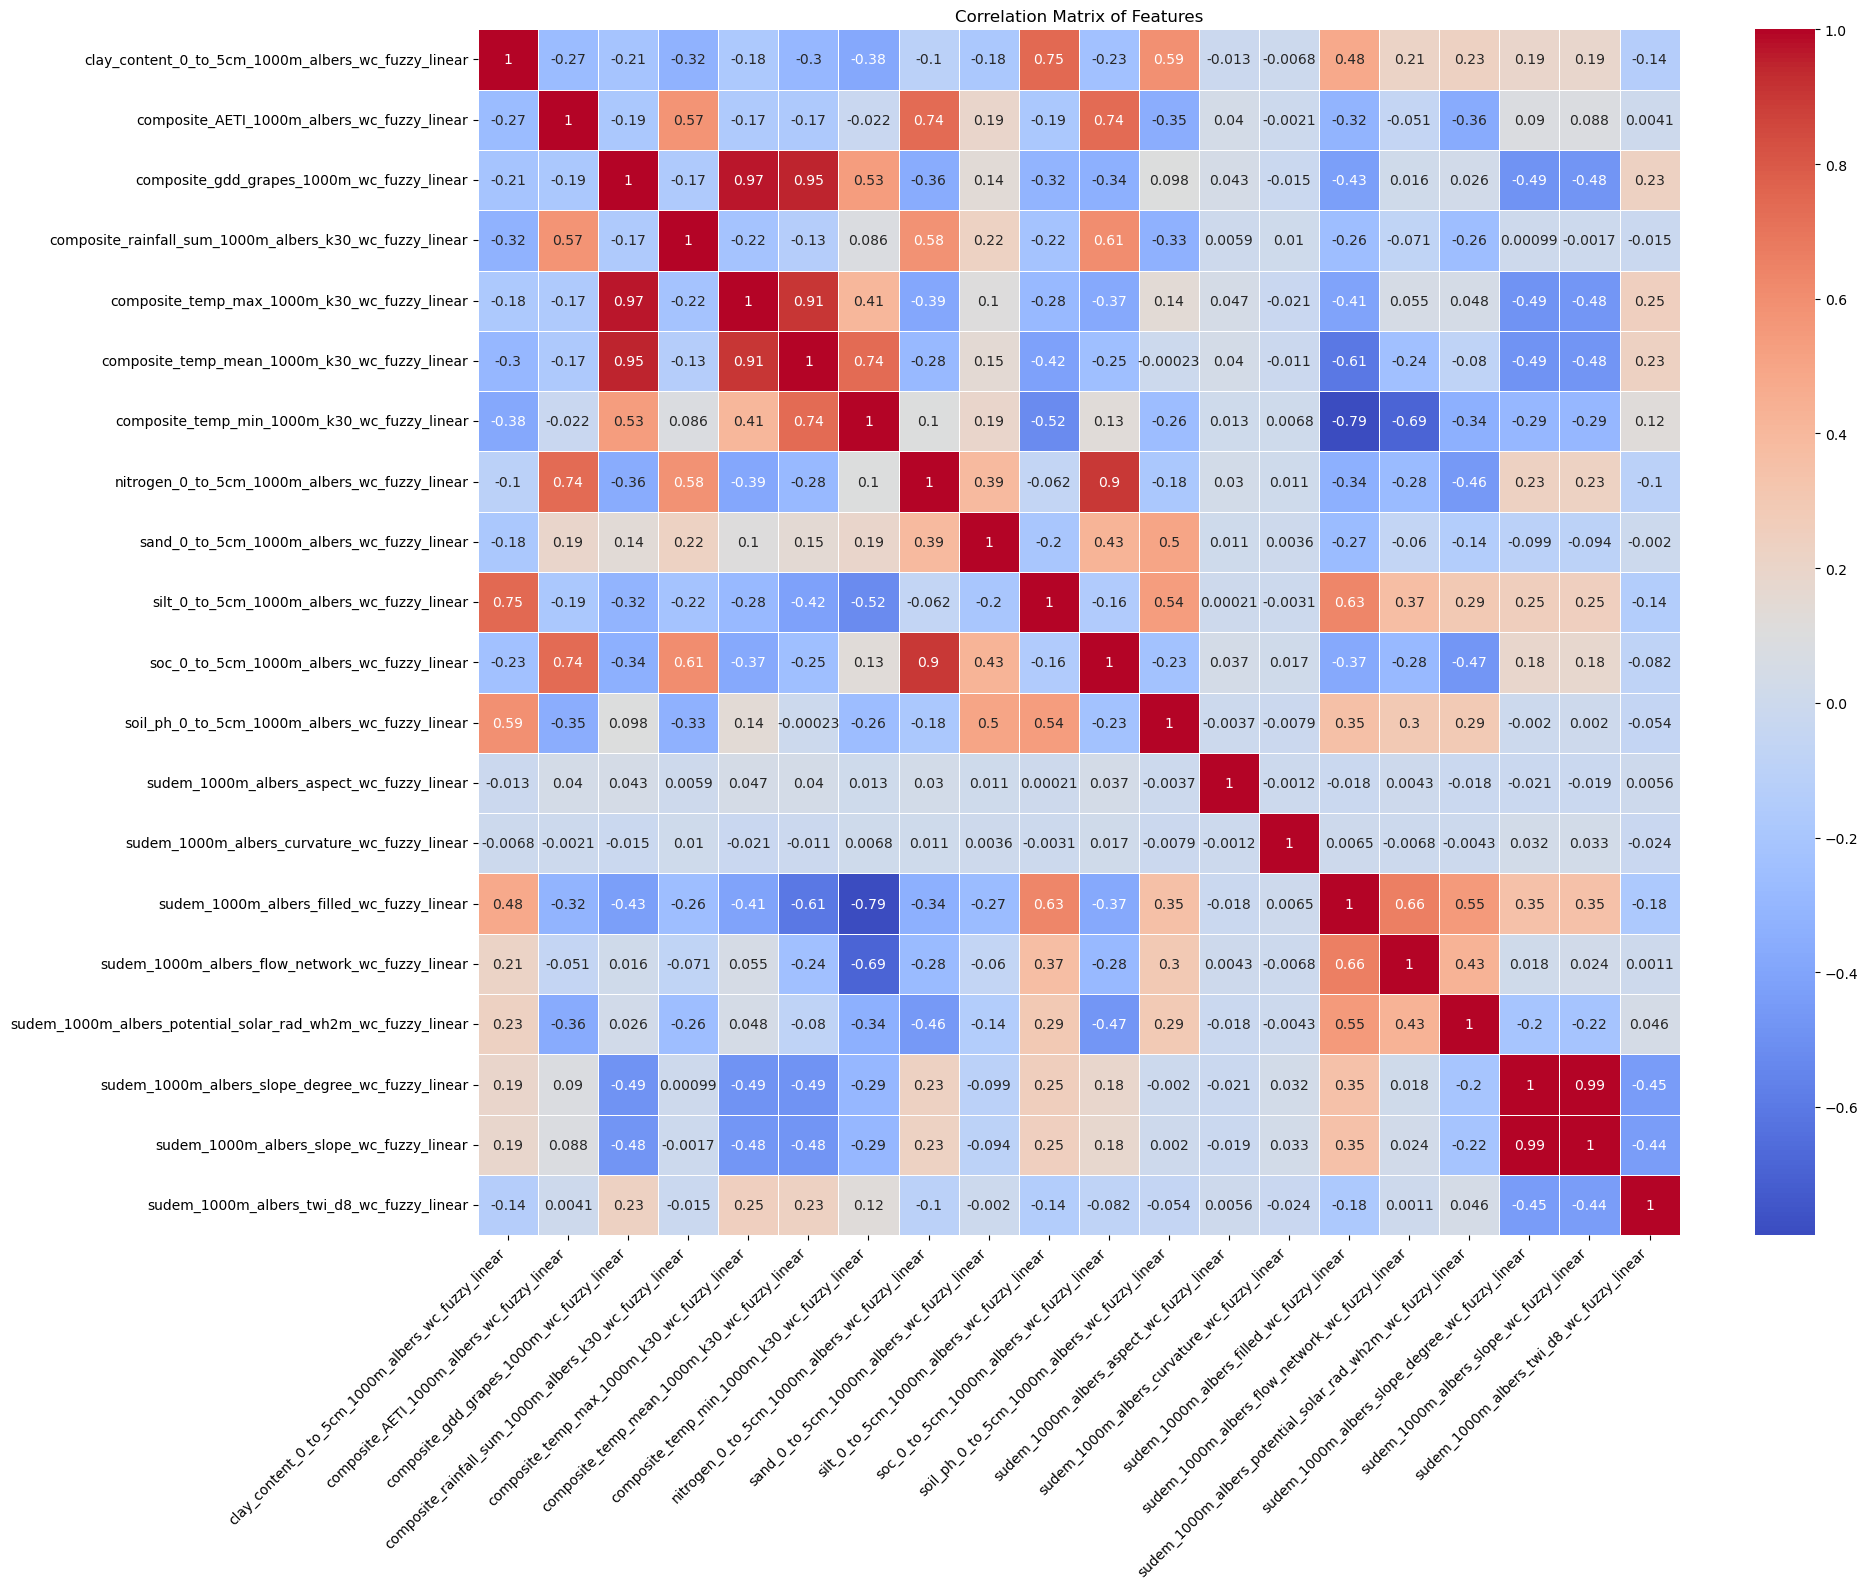

In [24]:
# Correlation matrix of features

# drop OID__, POINT_X, POINT_Y, suitability columns 
columns_to_drop = ['suitability', 'OID_', 'POINT_X', 'POINT_Y'] 
features = combined_df.drop(columns=columns_to_drop)

plt.figure(figsize=(20, 16))
correlation_matrix = features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

<Axes: >

<Axes: xlabel='clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear', ylabel='Count'>

Text(0.5, 1.0, 'clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear')

<Axes: >

...

<Axes: xlabel='nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear', ylabel='Count'>

Text(0.5, 1.0, 'nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear')

<Axes: >

<Axes: xlabel='sand_0_to_5cm_1000m_albers_wc_fuzzy_linear', ylabel='Count'>

Text(0.5, 1.0, 'sand_0_to_5cm_1000m_albers_wc_fuzzy_linear')

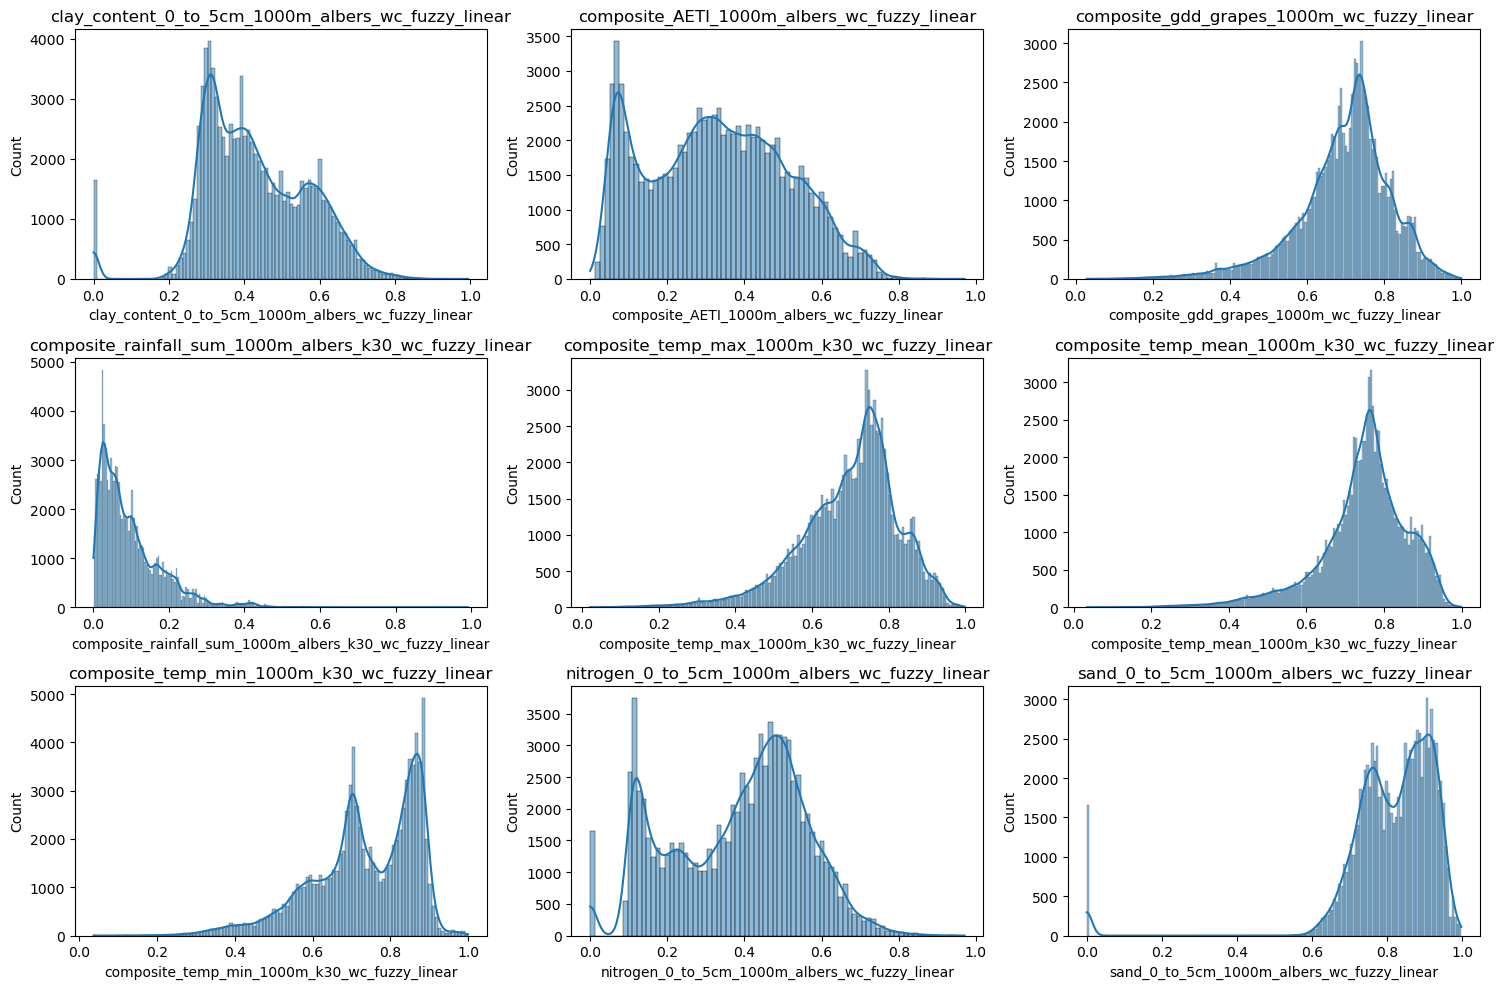

In [25]:
# Distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(combined_df.columns[3:12], 1):
    plt.subplot(3, 3, i)
    sns.histplot(combined_df[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

<Axes: >

<Axes: xlabel='silt_0_to_5cm_1000m_albers_wc_fuzzy_linear', ylabel='Count'>

Text(0.5, 1.0, 'silt_0_to_5cm_1000m_albers_wc_fuzzy_linear')

<Axes: >

...

<Axes: xlabel='sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear', ylabel='Count'>

Text(0.5, 1.0, 'sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear')

<Axes: >

<Axes: xlabel='sudem_1000m_albers_slope_degree_wc_fuzzy_linear', ylabel='Count'>

Text(0.5, 1.0, 'sudem_1000m_albers_slope_degree_wc_fuzzy_linear')

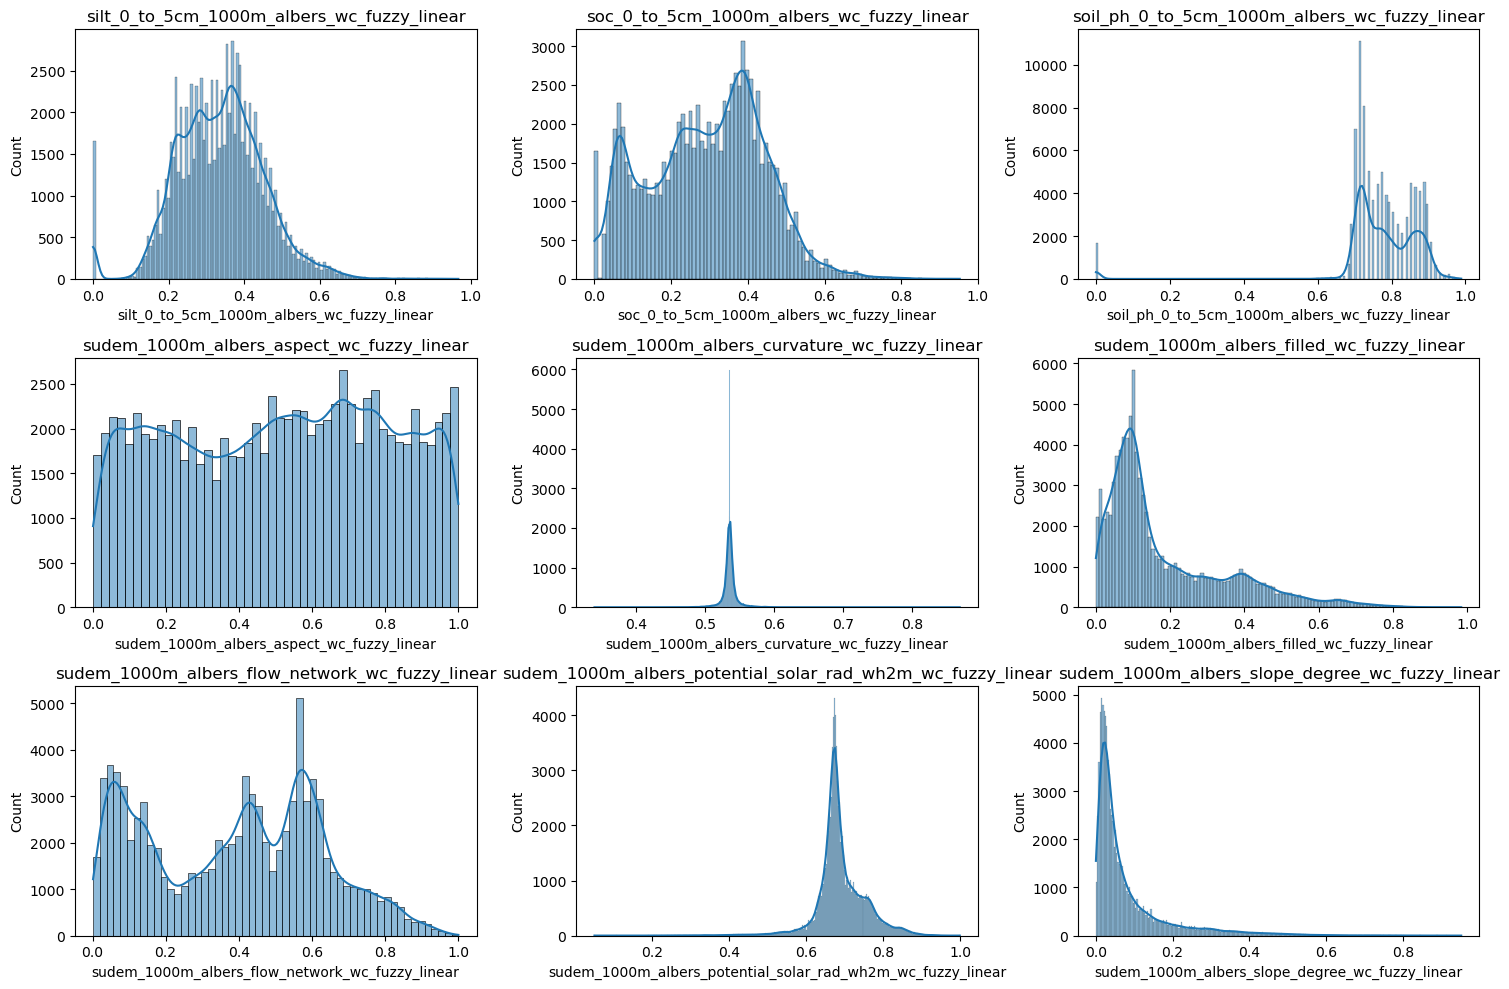

In [26]:
# Distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(combined_df.columns[12:21], 1):
    plt.subplot(3, 3, i)
    sns.histplot(combined_df[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

<Axes: >

<Axes: xlabel='sudem_1000m_albers_slope_wc_fuzzy_linear', ylabel='Count'>

Text(0.5, 1.0, 'sudem_1000m_albers_slope_wc_fuzzy_linear')

<Axes: >

<Axes: xlabel='sudem_1000m_albers_twi_d8_wc_fuzzy_linear', ylabel='Count'>

Text(0.5, 1.0, 'sudem_1000m_albers_twi_d8_wc_fuzzy_linear')

<Axes: >

<Axes: xlabel='suitability', ylabel='Count'>

Text(0.5, 1.0, 'suitability')

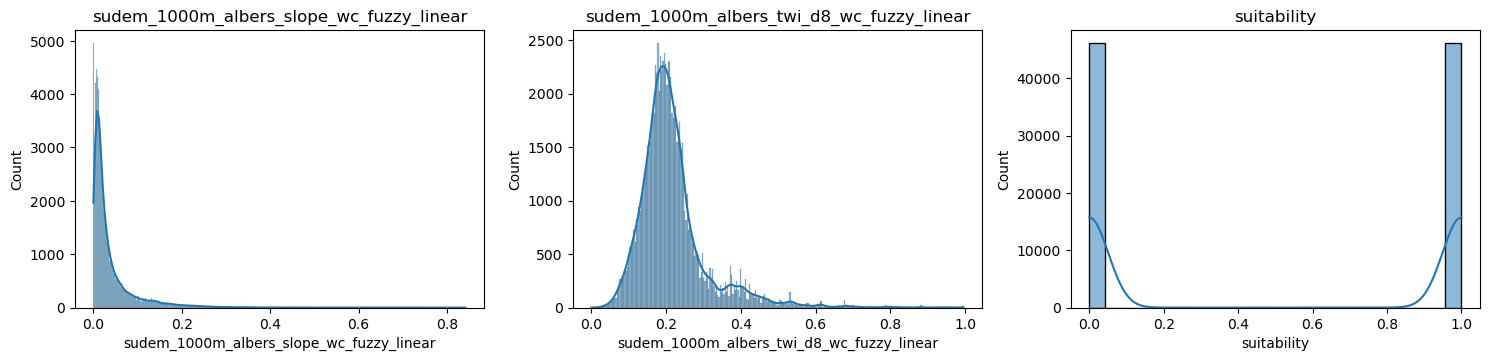

In [27]:
# Distribution of each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(combined_df.columns[21:], 1):
    plt.subplot(3, 3, i)
    sns.histplot(combined_df[column], kde=True)
    plt.title(column)
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

Text(0.5, 1.0, 'Geographical Distribution of Points')

Text(0.5, 0, 'Longitude')

Text(0, 0.5, 'Latitude')

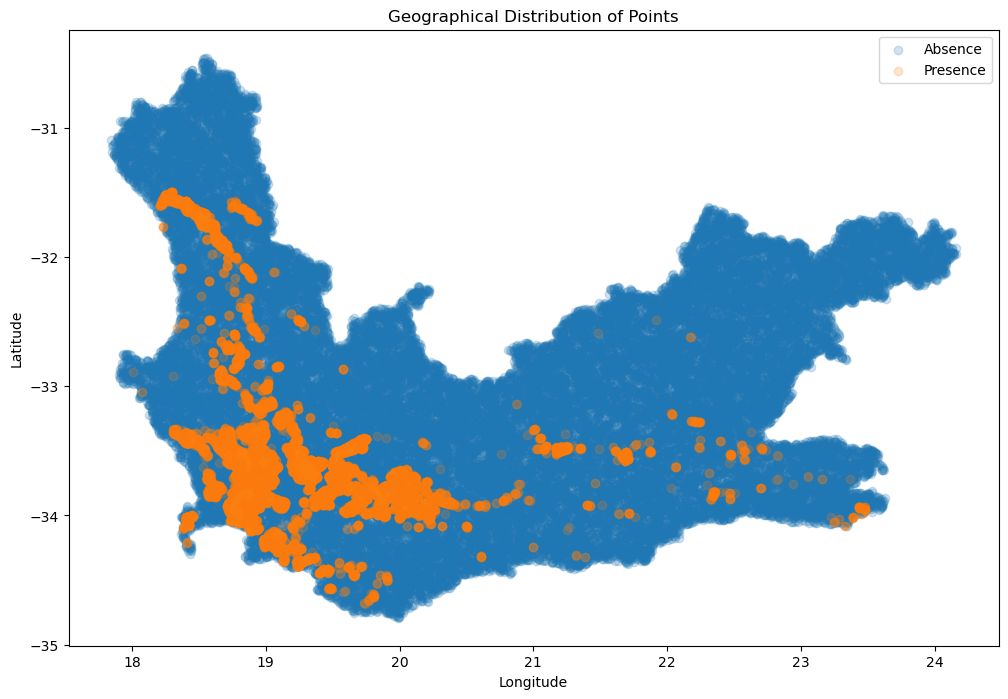

In [28]:
# Geographical distribution (if latitude and longitude are available)
plt.figure(figsize=(12, 8))
plt.scatter(combined_df[combined_df['suitability'] == 0]['POINT_X'], 
            combined_df[combined_df['suitability'] == 0]['POINT_Y'], 
            alpha=0.2, label='Absence')
plt.scatter(combined_df[combined_df['suitability'] == 1]['POINT_X'], 
            combined_df[combined_df['suitability'] == 1]['POINT_Y'], 
            alpha=0.2, label='Presence')
plt.title('Geographical Distribution of Points')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

## Model training

In [75]:
# I can potentially look at normalizing the data see the example below

# from sklearn.preprocessing import StandardScaler

# Normalizing 
# No need to normalize binary or Likert Scaled columns. 

# columns_to_normalize = df.columns[1:5] 

# Initialize the StandardScaler

# scaler = StandardScaler()

# Fit and transform the selected columns

# df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

In [103]:
# This cell is applicable for the standardised data only
# Here I am dropping duplicates in my combined dataframe 
# I am doing this before splitting the data into training and testing sets

combined_df = combined_df.drop_duplicates()
combined_df.shape


(92219, 24)

In [104]:
# columns to drop
# I am dropping the suitability column because it is the target variable and OID column because it is an identifier and to reduce overfitting and noise 
# I can potentially drop the geometry columns as well?? 
# We can potentially drop POINT_X and POINT_Y because they are location identifiers rather than predictive features
# But if geographical location is important we can potentially keep them
columns_to_drop = ['suitability', 'OID_', 'POINT_X', 'POINT_Y'] 

# features/ predictor variables
X = combined_df.drop(columns=columns_to_drop)

# target variable (0 and 1)
y = combined_df['suitability']




In [105]:
# Create a train/test split with 20% as test size
# random_state controls the shuffling applied to the data before applying the split
# What does the value 42 signify now?
# What difference would it have made if I had use another value??
# I believe that 42 has been determined to be an optimal/default value for best model performance


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Scale the features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [113]:
# check for duplicates between training and test data (this checks for duplicates in the respective df)
# X_train.duplicated().sum()
# X_test.duplicated().sum()

# Create complete datasets for training and testing
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

train_data.shape
test_data.shape

# Check for duplicates between training and testing data
duplicates_df = pd.concat([train_data, test_data])
duplicates = pd.concat([train_data, test_data]).duplicated().sum()

duplicates_df.size

print(f"Number of duplicates between training and testing data: {duplicates}")

# to see the actual duplicate rows:
# duplicate_rows = pd.concat([train_data, test_data])[pd.concat([train_data, test_data]).duplicated(keep=False)]
# print("Duplicate rows:")
# print(duplicate_rows)

16778

1811

(73775, 21)

(18444, 21)

1936599

Number of duplicates between training and testing data: 22792


In [114]:

# Initialize the XGBoost regressor
# There is also a XGBClassifier 
#  The XGBRegressor class in the XGBoost Python API is used for regression problems 

xgb_model = XGBRegressor(objective='reg:logistic', random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)



# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# accuracy = accuracy_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# print(y_pred[0:100])
# Model results without ndvi, roads, and rivers
# Mean Absolute Error: 0.0532
# Mean Squared Error: 0.0258
# R-squared Score: 0.8967


# Model results from using standardised data (although the data has duplicates 22792)
# Mean Absolute Error: 0.0574
# Mean Squared Error: 0.0271
# R-squared Score: 0.8915

# Model results from using standardised data after removing most the duplicates between traing and testing data (4444)
# Mean Absolute Error: 0.0573
# Mean Squared Error: 0.0269
# R-squared Score: 0.8924



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, objective='reg:logistic', ...)

Mean Absolute Error: 0.0584
Mean Squared Error: 0.0275
R-squared Score: 0.8901


## Predicting suitability for new locations

In [138]:
new_locations_df = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/input_points_data/points_for_predicting/wc_points_from_composite_raster_standardised_data.csv', delimiter=';')

print("New locations", new_locations_df.shape)

New locations (129425, 23)


In [139]:
print("New locations")
new_locations_df.head()
new_locations_df.describe()
new_locations_df.shape

New locations


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc_fuzzy_linear,sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear,sudem_1000m_albers_twi_d8_wc_fuzzy_linear,sudem_1000m_albers_slope_degree_wc_fuzzy_linear,sudem_1000m_albers_slope_wc_fuzzy_linear,sudem_1000m_albers_aspect_wc_fuzzy_linear,sudem_1000m_albers_flow_network_wc_fuzzy_linear,sudem_1000m_albers_curvature_wc_fuzzy_linear,composite_temp_mean_1000m_k30_wc_fuzzy_linear,composite_temp_min_1000m_k30_wc_fuzzy_linear,composite_temp_max_1000m_k30_wc_fuzzy_linear,composite_rainfall_sum_1000m_k30_wc_fuzzy_linear,composite_gdd_grapes_1000m_wc_fuzzy_linear,composite_AETI_1000m_albers_wc_fuzzy_linear,nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear,sand_0_to_5cm_1000m_albers_wc_fuzzy_linear,soc_0_to_5cm_1000m_albers_wc_fuzzy_linear,clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear,soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear,silt_0_to_5cm_1000m_albers_wc_fuzzy_linear
0,1,"17,881470420327695","-32,989886923320924","0,0059738","0,6699376","0,2579435","0,0147801","0,0065625","0,0256191","0,0021827","0,5380708",NaN,NaN,NaN,"0,0127799",NaN,"0,1273299","0,3553114","0,8978434","0,4750859","0,4250765","0,8181818","0,1854839"
1,2,"17,891267569177280","-32,989916735369036","0,0118792","0,6644664","0,1659566","0,0194051","0,0086147","0,8197930","0,0058287","0,5350314","0,7976424","0,8810638","0,6792001","0,0132079","0,6784292","0,0867124","0,3553114","0,9216799","0,3934708","0,3700306","0,7954546","0,1801075"
2,3,"17,901064718274046","-32,989946506368661","0,0109936","0,6597513","0,2071873","0,0473208","0,0210178","0,7879319","0,0063496","0,5389091","0,7927157","0,8766274","0,6746235","0,0136827","0,6736473","0,0605952","0,3516484","0,9091941","0,2774914","0,3425076","0,7840909","0,2338710"
3,4,"17,910861867617651","-32,989976236319599","0,0115722","0,6568763","0,2317516","0,0216576","0,0096144","0,6336716","0,0118525","0,5358425","0,7659909","0,8590809","0,6441815","0,0141713","0,6446151","0,0548833","0,3076923","0,9443814","0,2680412","0,3149847","0,7954546","0,1774193"
4,5,"17,920659017207750","-32,990005925221347","0,0222110","0,6433477","0,1650212","0,0793098","0,0352928","0,6791371","0,0148689","0,5445921","0,7764927","0,8646919","0,6572266","0,0146734","0,6564275","0,0777169","0,3351648","0,9511918","0,3109966","0,3119266","0,7727273","0,1612903"


,OID_
count,129425.000000
mean,64713.000000
std,37361.923632
min,1.000000
25%,32357.000000
50%,64713.000000
75%,97069.000000
max,129425.000000


(129425, 23)

In [140]:
new_locations_df.isnull().sum()

OID_                                                             0
POINT_X                                                          0
POINT_Y                                                          0
sudem_1000m_albers_filled_wc_fuzzy_linear                       19
sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear      0
sudem_1000m_albers_twi_d8_wc_fuzzy_linear                       29
sudem_1000m_albers_slope_degree_wc_fuzzy_linear                 29
sudem_1000m_albers_slope_wc_fuzzy_linear                        29
sudem_1000m_albers_aspect_wc_fuzzy_linear                       24
sudem_1000m_albers_flow_network_wc_fuzzy_linear                409
sudem_1000m_albers_curvature_wc_fuzzy_linear                   409
composite_temp_mean_1000m_k30_wc_fuzzy_linear                  602
composite_temp_min_1000m_k30_wc_fuzzy_linear                   602
composite_temp_max_1000m_k30_wc_fuzzy_linear                   602
composite_rainfall_sum_1000m_k30_wc_fuzzy_linear              

In [141]:
new_locations_df.dtypes

OID_                                                            int64
POINT_X                                                        object
POINT_Y                                                        object
sudem_1000m_albers_filled_wc_fuzzy_linear                      object
sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear    object
sudem_1000m_albers_twi_d8_wc_fuzzy_linear                      object
sudem_1000m_albers_slope_degree_wc_fuzzy_linear                object
sudem_1000m_albers_slope_wc_fuzzy_linear                       object
sudem_1000m_albers_aspect_wc_fuzzy_linear                      object
sudem_1000m_albers_flow_network_wc_fuzzy_linear                object
sudem_1000m_albers_curvature_wc_fuzzy_linear                   object
composite_temp_mean_1000m_k30_wc_fuzzy_linear                  object
composite_temp_min_1000m_k30_wc_fuzzy_linear                   object
composite_temp_max_1000m_k30_wc_fuzzy_linear                   object
composite_rainfall_s

In [63]:
# Should not be necessary if i label my columns correctly from the start
new_locations_df.rename(columns={'composite_rainfall_sum_1000m_k30_wc_fuzzy_linear': 'composite_rainfall_sum_1000m_albers_k30_wc_fuzzy_linear'}, inplace=True)

In [123]:
# Drop ndvi, roads and rivers since the new model was trained without them
new_locations_df = new_locations_df.drop(['ndvi_wc', 'euclidean_distance_roads_1000m_albers_wc', 'euclidean_distance_rivers_1000m_albers_wc'], axis=1)

In [142]:
# Converting the columns to float
# columns_to_convert_for_new_locations = ['POINT_X','POINT_Y','sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
#                         'sudem_1000m_albers_twi_d8_wc', 'sudem_1000m_albers_slope_degree_wc', 'sudem_1000m_albers_slope_wc',
#                         'sudem_1000m_albers_aspect_wc', 'sudem_1000m_albers_flow_network_wc', 'sudem_1000m_albers_curvature_wc',
#                         'composite_temp_mean_1000m_k30_wc','composite_temp_min_1000m_k30_wc', 'composite_temp_max_1000m_k30_wc',
#                         'composite_rainfall_sum_1000m_k30_wc', 'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc',
#                         'nitrogen_0_to_5cm_1000m_albers_wc', 'sand_0_to_5cm_1000m_albers_wc', 'soc_0_to_5cm_1000m_albers_wc',
#                         'clay_content_0_to_5cm_1000m_albers_wc', 'soil_ph_0_to_5cm_1000m_albers_wc', 'silt_0_to_5cm_1000m_albers_wc']

columns_to_convert_for_new_locations = ['POINT_X', 'POINT_Y', 'sudem_1000m_albers_filled_wc_fuzzy_linear', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear',
                        'sudem_1000m_albers_twi_d8_wc_fuzzy_linear', 'sudem_1000m_albers_slope_degree_wc_fuzzy_linear', 'sudem_1000m_albers_slope_wc_fuzzy_linear',
                        'sudem_1000m_albers_aspect_wc_fuzzy_linear', 'sudem_1000m_albers_flow_network_wc_fuzzy_linear', 'sudem_1000m_albers_curvature_wc_fuzzy_linear',
                        'composite_temp_mean_1000m_k30_wc_fuzzy_linear', 'composite_temp_min_1000m_k30_wc_fuzzy_linear', 'composite_temp_max_1000m_k30_wc_fuzzy_linear',
                        'composite_rainfall_sum_1000m_k30_wc_fuzzy_linear', 'composite_gdd_grapes_1000m_wc_fuzzy_linear', 'composite_AETI_1000m_albers_wc_fuzzy_linear',
                        'nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'sand_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'soc_0_to_5cm_1000m_albers_wc_fuzzy_linear',
                        'clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'silt_0_to_5cm_1000m_albers_wc_fuzzy_linear']


for col in columns_to_convert_for_new_locations:
    new_locations_df[col] = clean_and_convert(new_locations_df[col])

In [143]:
# checking the data types again

new_locations_df.dtypes

OID_                                                             int64
POINT_X                                                        float64
POINT_Y                                                        float64
sudem_1000m_albers_filled_wc_fuzzy_linear                      float64
sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear    float64
sudem_1000m_albers_twi_d8_wc_fuzzy_linear                      float64
sudem_1000m_albers_slope_degree_wc_fuzzy_linear                float64
sudem_1000m_albers_slope_wc_fuzzy_linear                       float64
sudem_1000m_albers_aspect_wc_fuzzy_linear                      float64
sudem_1000m_albers_flow_network_wc_fuzzy_linear                float64
sudem_1000m_albers_curvature_wc_fuzzy_linear                   float64
composite_temp_mean_1000m_k30_wc_fuzzy_linear                  float64
composite_temp_min_1000m_k30_wc_fuzzy_linear                   float64
composite_temp_max_1000m_k30_wc_fuzzy_linear                   float64
compos

In [144]:
new_locations_df

# creating a new df called new_locations_df_2 to use for the csv file
new_locations_df_2 = new_locations_df.copy()

new_locations_df_2

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc_fuzzy_linear,sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear,sudem_1000m_albers_twi_d8_wc_fuzzy_linear,sudem_1000m_albers_slope_degree_wc_fuzzy_linear,sudem_1000m_albers_slope_wc_fuzzy_linear,sudem_1000m_albers_aspect_wc_fuzzy_linear,sudem_1000m_albers_flow_network_wc_fuzzy_linear,sudem_1000m_albers_curvature_wc_fuzzy_linear,composite_temp_mean_1000m_k30_wc_fuzzy_linear,composite_temp_min_1000m_k30_wc_fuzzy_linear,composite_temp_max_1000m_k30_wc_fuzzy_linear,composite_rainfall_sum_1000m_k30_wc_fuzzy_linear,composite_gdd_grapes_1000m_wc_fuzzy_linear,composite_AETI_1000m_albers_wc_fuzzy_linear,nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear,sand_0_to_5cm_1000m_albers_wc_fuzzy_linear,soc_0_to_5cm_1000m_albers_wc_fuzzy_linear,clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear,soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear,silt_0_to_5cm_1000m_albers_wc_fuzzy_linear
0,1,17.881470,-32.989887,0.005974,0.669938,0.257943,0.014780,0.006562,0.025619,0.002183,0.538071,NaN,NaN,NaN,0.012780,NaN,0.127330,0.355311,0.897843,0.475086,0.425077,0.818182,0.185484
1,2,17.891268,-32.989917,0.011879,0.664466,0.165957,0.019405,0.008615,0.819793,0.005829,0.535031,0.797642,0.881064,0.679200,0.013208,0.678429,0.086712,0.355311,0.921680,0.393471,0.370031,0.795455,0.180108
2,3,17.901065,-32.989947,0.010994,0.659751,0.207187,0.047321,0.021018,0.787932,0.006350,0.538909,0.792716,0.876627,0.674624,0.013683,0.673647,0.060595,0.351648,0.909194,0.277491,0.342508,0.784091,0.233871
3,4,17.910862,-32.989976,0.011572,0.656876,0.231752,0.021658,0.009614,0.633672,0.011853,0.535842,0.765991,0.859081,0.644181,0.014171,0.644615,0.054883,0.307692,0.944381,0.268041,0.314985,0.795455,0.177419
4,5,17.920659,-32.990006,0.022211,0.643348,0.165021,0.079310,0.035293,0.679137,0.014869,0.544592,0.776493,0.864692,0.657227,0.014673,0.656428,0.077717,0.335165,0.951192,0.310997,0.311927,0.772727,0.161290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129420,129421,18.866353,-31.023826,0.133586,0.719131,0.195819,0.018088,0.008030,0.607455,0.326955,0.536882,0.938334,0.870888,0.927994,0.032705,0.866653,0.022530,0.142857,0.843360,0.073024,0.382263,0.920455,0.354839
129421,129422,18.876142,-31.023852,0.132145,0.723263,0.195530,0.027335,0.012135,0.248225,0.331217,0.538603,0.945207,0.874329,0.937139,0.032790,0.875194,0.027276,0.141026,0.843360,0.075601,0.406728,0.920455,0.336021
129422,129423,18.885930,-31.023877,0.128249,0.717982,0.198154,0.034079,0.015130,0.490702,0.330571,0.539190,0.948600,0.875592,0.941992,0.032873,0.879784,0.023468,0.139194,0.850170,0.076461,0.388379,0.920455,0.336021
129423,129424,18.895719,-31.023902,0.132230,0.716385,0.233732,0.020588,0.009140,0.300493,0.330361,0.544218,0.949627,0.875406,0.943916,0.032873,0.881693,0.030256,0.142857,0.852440,0.068728,0.403670,0.920455,0.314516


,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc_fuzzy_linear,sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear,sudem_1000m_albers_twi_d8_wc_fuzzy_linear,sudem_1000m_albers_slope_degree_wc_fuzzy_linear,sudem_1000m_albers_slope_wc_fuzzy_linear,sudem_1000m_albers_aspect_wc_fuzzy_linear,sudem_1000m_albers_flow_network_wc_fuzzy_linear,sudem_1000m_albers_curvature_wc_fuzzy_linear,composite_temp_mean_1000m_k30_wc_fuzzy_linear,composite_temp_min_1000m_k30_wc_fuzzy_linear,composite_temp_max_1000m_k30_wc_fuzzy_linear,composite_rainfall_sum_1000m_k30_wc_fuzzy_linear,composite_gdd_grapes_1000m_wc_fuzzy_linear,composite_AETI_1000m_albers_wc_fuzzy_linear,nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear,sand_0_to_5cm_1000m_albers_wc_fuzzy_linear,soc_0_to_5cm_1000m_albers_wc_fuzzy_linear,clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear,soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear,silt_0_to_5cm_1000m_albers_wc_fuzzy_linear
0,1,17.881470,-32.989887,0.005974,0.669938,0.257943,0.014780,0.006562,0.025619,0.002183,0.538071,NaN,NaN,NaN,0.012780,NaN,0.127330,0.355311,0.897843,0.475086,0.425077,0.818182,0.185484
1,2,17.891268,-32.989917,0.011879,0.664466,0.165957,0.019405,0.008615,0.819793,0.005829,0.535031,0.797642,0.881064,0.679200,0.013208,0.678429,0.086712,0.355311,0.921680,0.393471,0.370031,0.795455,0.180108
2,3,17.901065,-32.989947,0.010994,0.659751,0.207187,0.047321,0.021018,0.787932,0.006350,0.538909,0.792716,0.876627,0.674624,0.013683,0.673647,0.060595,0.351648,0.909194,0.277491,0.342508,0.784091,0.233871
3,4,17.910862,-32.989976,0.011572,0.656876,0.231752,0.021658,0.009614,0.633672,0.011853,0.535842,0.765991,0.859081,0.644181,0.014171,0.644615,0.054883,0.307692,0.944381,0.268041,0.314985,0.795455,0.177419
4,5,17.920659,-32.990006,0.022211,0.643348,0.165021,0.079310,0.035293,0.679137,0.014869,0.544592,0.776493,0.864692,0.657227,0.014673,0.656428,0.077717,0.335165,0.951192,0.310997,0.311927,0.772727,0.161290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129420,129421,18.866353,-31.023826,0.133586,0.719131,0.195819,0.018088,0.008030,0.607455,0.326955,0.536882,0.938334,0.870888,0.927994,0.032705,0.866653,0.022530,0.142857,0.843360,0.073024,0.382263,0.920455,0.354839
129421,129422,18.876142,-31.023852,0.132145,0.723263,0.195530,0.027335,0.012135,0.248225,0.331217,0.538603,0.945207,0.874329,0.937139,0.032790,0.875194,0.027276,0.141026,0.843360,0.075601,0.406728,0.920455,0.336021
129422,129423,18.885930,-31.023877,0.128249,0.717982,0.198154,0.034079,0.015130,0.490702,0.330571,0.539190,0.948600,0.875592,0.941992,0.032873,0.879784,0.023468,0.139194,0.850170,0.076461,0.388379,0.920455,0.336021
129423,129424,18.895719,-31.023902,0.132230,0.716385,0.233732,0.020588,0.009140,0.300493,0.330361,0.544218,0.949627,0.875406,0.943916,0.032873,0.881693,0.030256,0.142857,0.852440,0.068728,0.403670,0.920455,0.314516


In [145]:
def interpolate_columns(df, columns):
    for col in columns:
        df[col].interpolate(method='linear', inplace=True)
    return df

In [146]:
# interpolate the columns with null values

# columns_to_interpolate_for_new_locations = ['sudem_1000m_albers_filled_wc', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc',
#                                             'sudem_1000m_albers_twi_d8_wc', 'sudem_1000m_albers_slope_degree_wc', 'sudem_1000m_albers_slope_wc',
#                                             'sudem_1000m_albers_aspect_wc', 'sudem_1000m_albers_flow_network_wc', 'sudem_1000m_albers_curvature_wc',
#                                             'composite_temp_mean_1000m_k30_wc','composite_temp_min_1000m_k30_wc', 'composite_temp_max_1000m_k30_wc',
#                                             'composite_rainfall_sum_1000m_k30_wc', 'composite_gdd_grapes_1000m_wc', 'composite_AETI_1000m_albers_wc',
#                                             'nitrogen_0_to_5cm_1000m_albers_wc', 'sand_0_to_5cm_1000m_albers_wc', 'soc_0_to_5cm_1000m_albers_wc',
#                                             'clay_content_0_to_5cm_1000m_albers_wc', 'soil_ph_0_to_5cm_1000m_albers_wc', 'silt_0_to_5cm_1000m_albers_wc']


columns_to_interpolate_for_new_locations = ['POINT_X', 'POINT_Y', 'sudem_1000m_albers_filled_wc_fuzzy_linear', 'sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear',
                        'sudem_1000m_albers_twi_d8_wc_fuzzy_linear', 'sudem_1000m_albers_slope_degree_wc_fuzzy_linear', 'sudem_1000m_albers_slope_wc_fuzzy_linear',
                        'sudem_1000m_albers_aspect_wc_fuzzy_linear', 'sudem_1000m_albers_flow_network_wc_fuzzy_linear', 'sudem_1000m_albers_curvature_wc_fuzzy_linear',
                        'composite_temp_mean_1000m_k30_wc_fuzzy_linear', 'composite_temp_min_1000m_k30_wc_fuzzy_linear', 'composite_temp_max_1000m_k30_wc_fuzzy_linear',
                        'composite_rainfall_sum_1000m_k30_wc_fuzzy_linear', 'composite_gdd_grapes_1000m_wc_fuzzy_linear', 'composite_AETI_1000m_albers_wc_fuzzy_linear',
                        'nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'sand_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'soc_0_to_5cm_1000m_albers_wc_fuzzy_linear',
                        'clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'silt_0_to_5cm_1000m_albers_wc_fuzzy_linear']


interpolate_columns(new_locations_df, columns_to_interpolate_for_new_locations)

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc_fuzzy_linear,sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear,sudem_1000m_albers_twi_d8_wc_fuzzy_linear,sudem_1000m_albers_slope_degree_wc_fuzzy_linear,sudem_1000m_albers_slope_wc_fuzzy_linear,sudem_1000m_albers_aspect_wc_fuzzy_linear,sudem_1000m_albers_flow_network_wc_fuzzy_linear,sudem_1000m_albers_curvature_wc_fuzzy_linear,composite_temp_mean_1000m_k30_wc_fuzzy_linear,composite_temp_min_1000m_k30_wc_fuzzy_linear,composite_temp_max_1000m_k30_wc_fuzzy_linear,composite_rainfall_sum_1000m_k30_wc_fuzzy_linear,composite_gdd_grapes_1000m_wc_fuzzy_linear,composite_AETI_1000m_albers_wc_fuzzy_linear,nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear,sand_0_to_5cm_1000m_albers_wc_fuzzy_linear,soc_0_to_5cm_1000m_albers_wc_fuzzy_linear,clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear,soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear,silt_0_to_5cm_1000m_albers_wc_fuzzy_linear
0,1,17.881470,-32.989887,0.005974,0.669938,0.257943,0.014780,0.006562,0.025619,0.002183,0.538071,NaN,NaN,NaN,0.012780,NaN,0.127330,0.355311,0.897843,0.475086,0.425077,0.818182,0.185484
1,2,17.891268,-32.989917,0.011879,0.664466,0.165957,0.019405,0.008615,0.819793,0.005829,0.535031,0.797642,0.881064,0.679200,0.013208,0.678429,0.086712,0.355311,0.921680,0.393471,0.370031,0.795455,0.180108
2,3,17.901065,-32.989947,0.010994,0.659751,0.207187,0.047321,0.021018,0.787932,0.006350,0.538909,0.792716,0.876627,0.674624,0.013683,0.673647,0.060595,0.351648,0.909194,0.277491,0.342508,0.784091,0.233871
3,4,17.910862,-32.989976,0.011572,0.656876,0.231752,0.021658,0.009614,0.633672,0.011853,0.535842,0.765991,0.859081,0.644181,0.014171,0.644615,0.054883,0.307692,0.944381,0.268041,0.314985,0.795455,0.177419
4,5,17.920659,-32.990006,0.022211,0.643348,0.165021,0.079310,0.035293,0.679137,0.014869,0.544592,0.776493,0.864692,0.657227,0.014673,0.656428,0.077717,0.335165,0.951192,0.310997,0.311927,0.772727,0.161290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129420,129421,18.866353,-31.023826,0.133586,0.719131,0.195819,0.018088,0.008030,0.607455,0.326955,0.536882,0.938334,0.870888,0.927994,0.032705,0.866653,0.022530,0.142857,0.843360,0.073024,0.382263,0.920455,0.354839
129421,129422,18.876142,-31.023852,0.132145,0.723263,0.195530,0.027335,0.012135,0.248225,0.331217,0.538603,0.945207,0.874329,0.937139,0.032790,0.875194,0.027276,0.141026,0.843360,0.075601,0.406728,0.920455,0.336021
129422,129423,18.885930,-31.023877,0.128249,0.717982,0.198154,0.034079,0.015130,0.490702,0.330571,0.539190,0.948600,0.875592,0.941992,0.032873,0.879784,0.023468,0.139194,0.850170,0.076461,0.388379,0.920455,0.336021
129423,129424,18.895719,-31.023902,0.132230,0.716385,0.233732,0.020588,0.009140,0.300493,0.330361,0.544218,0.949627,0.875406,0.943916,0.032873,0.881693,0.030256,0.142857,0.852440,0.068728,0.403670,0.920455,0.314516


In [147]:
new_locations_df.isnull().sum()
new_locations_df.shape

OID_                                                           0
POINT_X                                                        0
POINT_Y                                                        0
sudem_1000m_albers_filled_wc_fuzzy_linear                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear    0
sudem_1000m_albers_twi_d8_wc_fuzzy_linear                      0
sudem_1000m_albers_slope_degree_wc_fuzzy_linear                0
sudem_1000m_albers_slope_wc_fuzzy_linear                       0
sudem_1000m_albers_aspect_wc_fuzzy_linear                      0
sudem_1000m_albers_flow_network_wc_fuzzy_linear                0
sudem_1000m_albers_curvature_wc_fuzzy_linear                   0
composite_temp_mean_1000m_k30_wc_fuzzy_linear                  1
composite_temp_min_1000m_k30_wc_fuzzy_linear                   1
composite_temp_max_1000m_k30_wc_fuzzy_linear                   1
composite_rainfall_sum_1000m_k30_wc_fuzzy_linear               0
composite_gdd_grapes_1000

(129425, 23)

In [148]:
new_locations_df.dropna(inplace=True)
new_locations_df.isnull().sum()
new_locations_df.shape

OID_                                                           0
POINT_X                                                        0
POINT_Y                                                        0
sudem_1000m_albers_filled_wc_fuzzy_linear                      0
sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear    0
sudem_1000m_albers_twi_d8_wc_fuzzy_linear                      0
sudem_1000m_albers_slope_degree_wc_fuzzy_linear                0
sudem_1000m_albers_slope_wc_fuzzy_linear                       0
sudem_1000m_albers_aspect_wc_fuzzy_linear                      0
sudem_1000m_albers_flow_network_wc_fuzzy_linear                0
sudem_1000m_albers_curvature_wc_fuzzy_linear                   0
composite_temp_mean_1000m_k30_wc_fuzzy_linear                  0
composite_temp_min_1000m_k30_wc_fuzzy_linear                   0
composite_temp_max_1000m_k30_wc_fuzzy_linear                   0
composite_rainfall_sum_1000m_k30_wc_fuzzy_linear               0
composite_gdd_grapes_1000

(129424, 23)

In [149]:
original_point_x = new_locations_df['POINT_X']
original_point_y = new_locations_df['POINT_Y']

In [150]:
# Make predictions
columns_to_drop_2 = ['OID_', 'POINT_X', 'POINT_Y']

new_locations_df.drop(columns=columns_to_drop_2, inplace=True)
feature_names = xgb_model.get_booster().feature_names
new_locations_df = new_locations_df[feature_names]
suitability_scores = xgb_model.predict(new_locations_df)


In [151]:
# Add predictions to the new_locations dataframe
new_locations_df['suitability_score'] = suitability_scores

# Might need to rearrange the columns according to point_x and point_y 

new_locations_df.describe



# Add POINT_X and POINT_Y columns back to the dataframe
new_locations_df['POINT_X'] = original_point_x
new_locations_df['POINT_Y'] = original_point_y

<bound method NDFrame.describe of         sudem_1000m_albers_filled_wc_fuzzy_linear  \
1                                        0.011879   
2                                        0.010994   
3                                        0.011572   
4                                        0.022211   
5                                        0.044662   
...                                           ...   
129420                                   0.133586   
129421                                   0.132145   
129422                                   0.128249   
129423                                   0.132230   
129424                                   0.135161   

        sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear  \
1                                                0.664466             
2                                                0.659751             
3                                                0.656876             
4                                            

In [152]:
# Save results
# If i can save it with point_x and point_y that would be great
new_locations_df.to_csv('../output_points_data/prediction_on_all_features/wc_predicted_suitability_no_ndvi-rivers-roads_fuzzy_linear.csv', index=False)

In [153]:
wc_predicted_suitability = pd.read_csv('C:/Users/charl/Desktop/__Thesis - Research/Github/vineyard-establishment-using-xgboost/output_points_data/prediction_on_all_features/wc_predicted_suitability_no_ndvi-rivers-roads_fuzzy_linear.csv')        

In [154]:
wc_predicted_suitability.head()
wc_predicted_suitability['suitability_score'].describe()

# So 

,sudem_1000m_albers_filled_wc_fuzzy_linear,sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear,sudem_1000m_albers_twi_d8_wc_fuzzy_linear,sudem_1000m_albers_slope_degree_wc_fuzzy_linear,sudem_1000m_albers_slope_wc_fuzzy_linear,sudem_1000m_albers_aspect_wc_fuzzy_linear,sudem_1000m_albers_flow_network_wc_fuzzy_linear,sudem_1000m_albers_curvature_wc_fuzzy_linear,composite_temp_mean_1000m_k30_wc_fuzzy_linear,composite_temp_min_1000m_k30_wc_fuzzy_linear,composite_temp_max_1000m_k30_wc_fuzzy_linear,composite_rainfall_sum_1000m_k30_wc_fuzzy_linear,composite_gdd_grapes_1000m_wc_fuzzy_linear,composite_AETI_1000m_albers_wc_fuzzy_linear,nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear,sand_0_to_5cm_1000m_albers_wc_fuzzy_linear,soc_0_to_5cm_1000m_albers_wc_fuzzy_linear,clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear,soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear,silt_0_to_5cm_1000m_albers_wc_fuzzy_linear,suitability_score,POINT_X,POINT_Y
0,0.011879,0.664466,0.165957,0.019405,0.008615,0.819793,0.005829,0.535031,0.797642,0.881064,0.679200,0.013208,0.678429,0.086712,0.355311,0.921680,0.393471,0.370031,0.795455,0.180108,0.000730,17.891268,-32.989917
1,0.010994,0.659751,0.207187,0.047321,0.021018,0.787932,0.006350,0.538909,0.792716,0.876627,0.674624,0.013683,0.673647,0.060595,0.351648,0.909194,0.277491,0.342508,0.784091,0.233871,0.013466,17.901065,-32.989947
2,0.011572,0.656876,0.231752,0.021658,0.009614,0.633672,0.011853,0.535842,0.765991,0.859081,0.644181,0.014171,0.644615,0.054883,0.307692,0.944381,0.268041,0.314985,0.795455,0.177419,0.000313,17.910862,-32.989976
3,0.022211,0.643348,0.165021,0.079310,0.035293,0.679137,0.014869,0.544592,0.776493,0.864692,0.657227,0.014673,0.656428,0.077717,0.335165,0.951192,0.310997,0.311927,0.772727,0.161290,0.001344,17.920659,-32.990006
4,0.044662,0.662563,0.241794,0.019546,0.008677,0.715289,0.014869,0.544592,0.764162,0.856282,0.643287,0.015188,0.642834,0.105697,0.415751,0.959137,0.348797,0.302752,0.806818,0.150538,0.002400,17.930456,-32.990036


count    1.294240e+05
mean     6.601029e-02
std      1.996749e-01
min      3.995775e-07
25%      1.070107e-04
50%      8.911146e-04
75%      1.086970e-02
max      9.997307e-01
Name: suitability_score, dtype: float64

In [155]:
# wc_vineyard_locations only has the suitability score
wc_vineyard_suitability_score = wc_predicted_suitability['suitability_score']

In [156]:
wc_vineyard_suitability_score.to_csv('../output_points_data/prediction_on_all_features/only_vineyard_suitability_score_wc_no_ndvi-rivers-roads_fuzzy_linear.csv', index=False)
new_locations_df_2

,OID_,POINT_X,POINT_Y,sudem_1000m_albers_filled_wc_fuzzy_linear,sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear,sudem_1000m_albers_twi_d8_wc_fuzzy_linear,sudem_1000m_albers_slope_degree_wc_fuzzy_linear,sudem_1000m_albers_slope_wc_fuzzy_linear,sudem_1000m_albers_aspect_wc_fuzzy_linear,sudem_1000m_albers_flow_network_wc_fuzzy_linear,sudem_1000m_albers_curvature_wc_fuzzy_linear,composite_temp_mean_1000m_k30_wc_fuzzy_linear,composite_temp_min_1000m_k30_wc_fuzzy_linear,composite_temp_max_1000m_k30_wc_fuzzy_linear,composite_rainfall_sum_1000m_k30_wc_fuzzy_linear,composite_gdd_grapes_1000m_wc_fuzzy_linear,composite_AETI_1000m_albers_wc_fuzzy_linear,nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear,sand_0_to_5cm_1000m_albers_wc_fuzzy_linear,soc_0_to_5cm_1000m_albers_wc_fuzzy_linear,clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear,soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear,silt_0_to_5cm_1000m_albers_wc_fuzzy_linear
0,1,17.881470,-32.989887,0.005974,0.669938,0.257943,0.014780,0.006562,0.025619,0.002183,0.538071,NaN,NaN,NaN,0.012780,NaN,0.127330,0.355311,0.897843,0.475086,0.425077,0.818182,0.185484
1,2,17.891268,-32.989917,0.011879,0.664466,0.165957,0.019405,0.008615,0.819793,0.005829,0.535031,0.797642,0.881064,0.679200,0.013208,0.678429,0.086712,0.355311,0.921680,0.393471,0.370031,0.795455,0.180108
2,3,17.901065,-32.989947,0.010994,0.659751,0.207187,0.047321,0.021018,0.787932,0.006350,0.538909,0.792716,0.876627,0.674624,0.013683,0.673647,0.060595,0.351648,0.909194,0.277491,0.342508,0.784091,0.233871
3,4,17.910862,-32.989976,0.011572,0.656876,0.231752,0.021658,0.009614,0.633672,0.011853,0.535842,0.765991,0.859081,0.644181,0.014171,0.644615,0.054883,0.307692,0.944381,0.268041,0.314985,0.795455,0.177419
4,5,17.920659,-32.990006,0.022211,0.643348,0.165021,0.079310,0.035293,0.679137,0.014869,0.544592,0.776493,0.864692,0.657227,0.014673,0.656428,0.077717,0.335165,0.951192,0.310997,0.311927,0.772727,0.161290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129420,129421,18.866353,-31.023826,0.133586,0.719131,0.195819,0.018088,0.008030,0.607455,0.326955,0.536882,0.938334,0.870888,0.927994,0.032705,0.866653,0.022530,0.142857,0.843360,0.073024,0.382263,0.920455,0.354839
129421,129422,18.876142,-31.023852,0.132145,0.723263,0.195530,0.027335,0.012135,0.248225,0.331217,0.538603,0.945207,0.874329,0.937139,0.032790,0.875194,0.027276,0.141026,0.843360,0.075601,0.406728,0.920455,0.336021
129422,129423,18.885930,-31.023877,0.128249,0.717982,0.198154,0.034079,0.015130,0.490702,0.330571,0.539190,0.948600,0.875592,0.941992,0.032873,0.879784,0.023468,0.139194,0.850170,0.076461,0.388379,0.920455,0.336021
129423,129424,18.895719,-31.023902,0.132230,0.716385,0.233732,0.020588,0.009140,0.300493,0.330361,0.544218,0.949627,0.875406,0.943916,0.032873,0.881693,0.030256,0.142857,0.852440,0.068728,0.403670,0.920455,0.314516


In [157]:
location_columns = ['POINT_X', 'POINT_Y']
merged_df = pd.concat([wc_vineyard_suitability_score, new_locations_df_2[location_columns]], axis=1)

merged_df

,suitability_score,POINT_X,POINT_Y
0,0.000730,17.881470,-32.989887
1,0.013466,17.891268,-32.989917
2,0.000313,17.901065,-32.989947
3,0.001344,17.910862,-32.989976
4,0.002400,17.920659,-32.990006
...,...,...,...
129420,0.000008,18.866353,-31.023826
129421,0.000009,18.876142,-31.023852
129422,0.000017,18.885930,-31.023877
129423,0.000008,18.895719,-31.023902


In [158]:
merged_df.isnull().sum()

suitability_score    1
POINT_X              0
POINT_Y              0
dtype: int64

In [159]:
# Points with suitability score
merged_df

,suitability_score,POINT_X,POINT_Y
0,0.000730,17.881470,-32.989887
1,0.013466,17.891268,-32.989917
2,0.000313,17.901065,-32.989947
3,0.001344,17.910862,-32.989976
4,0.002400,17.920659,-32.990006
...,...,...,...
129420,0.000008,18.866353,-31.023826
129421,0.000009,18.876142,-31.023852
129422,0.000017,18.885930,-31.023877
129423,0.000008,18.895719,-31.023902


In [52]:
# After this i go into ArcPro and create a point shapefile from the csv file using the XY to point tool
# I then create a raster from the point shapefile using the raster to point tool


## Feature importance

In [160]:
# Get feature importance
feature_importance = xgb_model.feature_importances_
feature_names = X.columns

In [161]:
# Sort features by importance
sorted_idx = np.argsort(feature_importance)
sorted_features = feature_names[sorted_idx]
sorted_features

Index(['sudem_1000m_albers_aspect_wc_fuzzy_linear',
       'sudem_1000m_albers_twi_d8_wc_fuzzy_linear',
       'sudem_1000m_albers_curvature_wc_fuzzy_linear',
       'sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear',
       'nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear',
       'composite_gdd_grapes_1000m_wc_fuzzy_linear',
       'sudem_1000m_albers_slope_wc_fuzzy_linear',
       'composite_rainfall_sum_1000m_k30_wc_fuzzy_linear',
       'soc_0_to_5cm_1000m_albers_wc_fuzzy_linear',
       'clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear',
       'sudem_1000m_albers_slope_degree_wc_fuzzy_linear',
       'sudem_1000m_albers_flow_network_wc_fuzzy_linear',
       'composite_temp_mean_1000m_k30_wc_fuzzy_linear',
       'composite_temp_min_1000m_k30_wc_fuzzy_linear',
       'composite_temp_max_1000m_k30_wc_fuzzy_linear',
       'sand_0_to_5cm_1000m_albers_wc_fuzzy_linear',
       'silt_0_to_5cm_1000m_albers_wc_fuzzy_linear',
       'soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_lin

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 20 artists>

([<matplotlib.axis.YTick at 0x251c72bba10>,
 [Text(0, 0, 'sudem_1000m_albers_aspect_wc_fuzzy_linear'),
  Text(0, 1, 'sudem_1000m_albers_twi_d8_wc_fuzzy_linear'),
  Text(0, 2, 'sudem_1000m_albers_curvature_wc_fuzzy_linear'),
  Text(0, 3, 'sudem_1000m_albers_potential_solar_rad_wh2m_wc_fuzzy_linear'),
  Text(0, 4, 'nitrogen_0_to_5cm_1000m_albers_wc_fuzzy_linear'),
  Text(0, 5, 'composite_gdd_grapes_1000m_wc_fuzzy_linear'),
  Text(0, 6, 'sudem_1000m_albers_slope_wc_fuzzy_linear'),
  Text(0, 7, 'composite_rainfall_sum_1000m_k30_wc_fuzzy_linear'),
  Text(0, 8, 'soc_0_to_5cm_1000m_albers_wc_fuzzy_linear'),
  Text(0, 9, 'clay_content_0_to_5cm_1000m_albers_wc_fuzzy_linear'),
  Text(0, 10, 'sudem_1000m_albers_slope_degree_wc_fuzzy_linear'),
  Text(0, 11, 'sudem_1000m_albers_flow_network_wc_fuzzy_linear'),
  Text(0, 12, 'composite_temp_mean_1000m_k30_wc_fuzzy_linear'),
  Text(0, 13, 'composite_temp_min_1000m_k30_wc_fuzzy_linear'),
  Text(0, 14, 'composite_temp_max_1000m_k30_wc_fuzzy_linear'),
  

Text(0.5, 0, 'Importance')

Text(0.5, 1.0, 'Feature Importance')

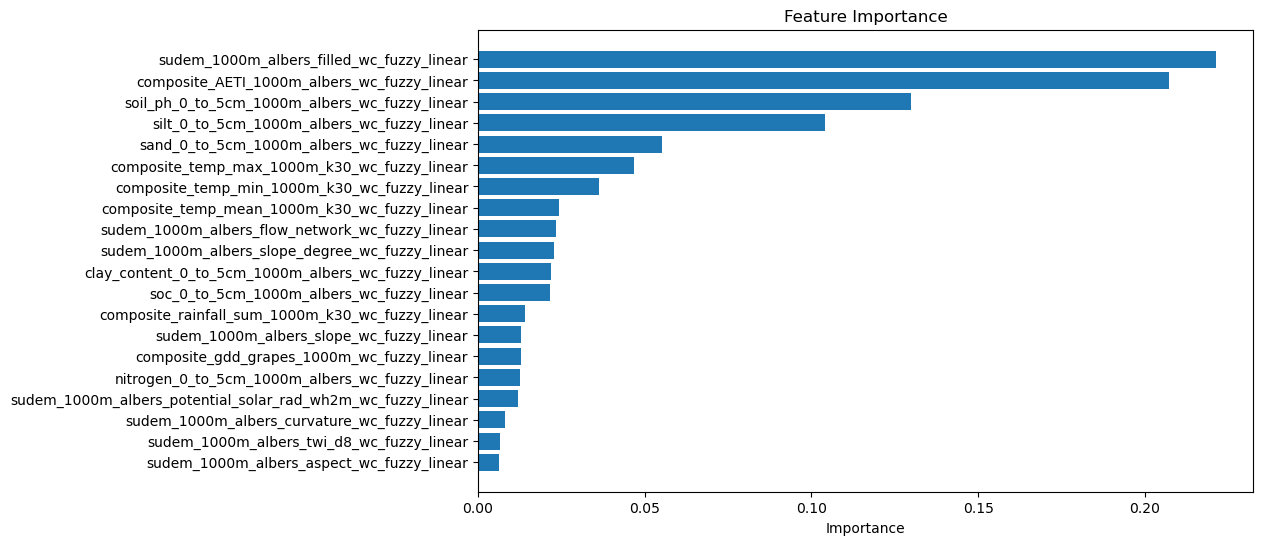

In [162]:
# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_features)), sorted_features)
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

In [163]:
# list of important features (top 5)
# This list is from the model that was trained with the standardised data

# 'sand_0_to_5cm_1000m_albers_wc_fuzzy_linear'
#  'silt_0_to_5cm_1000m_albers_wc_fuzzy_linear'
#  'soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear'
#  'composite_AETI_1000m_albers_wc_fuzzy_linear'
#  'sudem_1000m_albers_filled_wc_fuzzy_linear'

In [176]:
# top 5 features from the model that was trained with standardised data
top_features_fuzzy_linear = ['sand_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'silt_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear', 'composite_AETI_1000m_albers_wc_fuzzy_linear', 'sudem_1000m_albers_filled_wc_fuzzy_linear']   

In [177]:
# only get the top features from the training and testing data
X_train_top_features = X_train[top_features_fuzzy_linear]
X_test_top_features = X_test[top_features_fuzzy_linear]

X_train_top_features.head()
X_test_top_features.head()

# only get the top features from the points that are used for prediction
new_locations_df_top_features = new_locations_df[top_features_fuzzy_linear]

,sand_0_to_5cm_1000m_albers_wc_fuzzy_linear,silt_0_to_5cm_1000m_albers_wc_fuzzy_linear,soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear,composite_AETI_1000m_albers_wc_fuzzy_linear,sudem_1000m_albers_filled_wc_fuzzy_linear
73745,0.774120,0.400538,0.829545,0.081552,0.317086
19762,0.888763,0.282258,0.727273,0.424291,0.105088
35299,0.916004,0.244624,0.715909,0.583284,0.057620
63100,0.901249,0.225806,0.840909,0.199238,0.222505
211,0.849035,0.344086,0.761364,0.614423,0.178626


,sand_0_to_5cm_1000m_albers_wc_fuzzy_linear,silt_0_to_5cm_1000m_albers_wc_fuzzy_linear,soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear,composite_AETI_1000m_albers_wc_fuzzy_linear,sudem_1000m_albers_filled_wc_fuzzy_linear
54622,0.871737,0.276882,0.863636,0.150522,0.102986
88353,0.850170,0.290323,0.852273,0.086078,0.143555
2981,0.948922,0.212366,0.715909,0.551786,0.097730
5604,0.877412,0.322581,0.727273,0.408452,0.090555
23939,0.759364,0.400538,0.806818,0.463818,0.064842


In [178]:
# check for duplicates between training and testing data
X_train_top_features.duplicated().sum()
X_test_top_features.duplicated().sum()

# Create complete datasets for training and testing
top_features_train_data = pd.concat([X_train_top_features, y_train], axis=1)
top_features_test_data = pd.concat([X_test_top_features, y_test], axis=1)

top_features_train_data.shape
top_features_test_data.shape

# Check for duplicates between training and testing data
# top_features_duplicates_df = pd.concat([top_features_train_data, top_features_test_data])
duplicates = pd.concat([top_features_train_data, top_features_test_data]).duplicated().sum()

duplicates

28991

4343

(73775, 6)

(18444, 6)

37681

In [179]:
# Retraining the model with only the top features
# y_train does not change, since that is my prediction target (predictor variable/ target variable)

xgb_model_top = XGBRegressor(objective='reg:logistic', random_state=42)
xgb_model_top.fit(X_train_top_features, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, objective='reg:logistic', ...)

In [180]:
# Evaluate the new model
y_pred_top_features = xgb_model_top.predict(X_test_top_features)

mae = mean_absolute_error(y_test, y_pred_top_features)
mse_top = mean_squared_error(y_test, y_pred_top_features)
r2_top = r2_score(y_test, y_pred_top_features)

print(f"MAE (top features): {mae}")
print(f"MSE (top features): {mse_top}")
print(f"R2 (top features): {r2_top}")

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# model results with top features
# MAE (top features): 0.08452244689630961
# MSE (top features): 0.03966760123362389
# R2 (top features): 0.8413287997245789

MAE (top features): 0.08452244689630961
MSE (top features): 0.03966760123362389
R2 (top features): 0.8413287997245789


In [181]:
# Compare with original model's performance

# Make predictions on new locations
suitability_scores_top_features = xgb_model_top.predict(new_locations_df_top_features)

# Add predictions to the new_locations dataframe
new_locations_df_top_features['suitability_score_top_features'] = suitability_scores_top_features
new_locations_df_top_features['POINT_X'] = original_point_x
new_locations_df_top_features['POINT_Y'] = original_point_y

In [182]:
new_locations_df_top_features.head()
new_locations_df_top_features['suitability_score_top_features'].describe()

,sand_0_to_5cm_1000m_albers_wc_fuzzy_linear,silt_0_to_5cm_1000m_albers_wc_fuzzy_linear,soil_ph_0_to_5cm_1000m_albers_wc_fuzzy_linear,composite_AETI_1000m_albers_wc_fuzzy_linear,sudem_1000m_albers_filled_wc_fuzzy_linear,suitability_score_top_features,POINT_X,POINT_Y
1,0.921680,0.180108,0.795455,0.086712,0.011879,0.002127,17.891268,-32.989917
2,0.909194,0.233871,0.784091,0.060595,0.010994,0.008170,17.901065,-32.989947
3,0.944381,0.177419,0.795455,0.054883,0.011572,0.005993,17.910862,-32.989976
4,0.951192,0.161290,0.772727,0.077717,0.022211,0.005225,17.920659,-32.990006
5,0.959137,0.150538,0.806818,0.105697,0.044662,0.003412,17.930456,-32.990036


count    1.294240e+05
mean     9.282039e-02
std      2.267791e-01
min      2.332543e-07
25%      1.029002e-04
50%      1.576839e-03
75%      3.144259e-02
max      9.997144e-01
Name: suitability_score_top_features, dtype: float64

In [183]:
new_locations_df_top_features.to_csv('../output_points_data/prediction_on_important_features/wc_predicted_suitability_important_features_no_ndvi-rivers-roads_fuzzy_linear.csv', index=False)    